# Import Library

In [1]:
!pip install feature_engine

In [2]:
!pip install tensorflow

In [3]:
!pip install prophet

In [68]:
# Load Library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


# Data Processing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from feature_engine.outliers import Winsorizer



# Modelling
import tensorflow as tf
import keras
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
from tensorflow.keras.layers import Input, concatenate
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, BatchNormalization
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras import backend as K
from prophet import Prophet
import numpy as np


# Saving
import pickle

# Pre-Prosesing Data

## Data Loading

In [5]:
import os
import pandas as pd

# Path folder CSV
folder_path = "/workspaces/Polutan_Prediction/Data_Final/Final"

# Mapping lokasi ke angka
location_encoding = {
    "Jakarta_Utara": 1,
    "Jakarta_Barat": 2,
    "Jakarta_Selatan": 3,
    "Jakarta_Pusat": 4,
    "Jakarta_Timur": 5
}

preprocessed_data = {}

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        location_name = file.replace(".csv", "")
        file_path = os.path.join(folder_path, file)

        # Baca file CSV
        df = pd.read_csv(file_path)

        # Ubah kolom 'Date' ke datetime, lalu ekstrak Tahun/Bulan/Hari
        df['Date'] = pd.to_datetime(df['Date'])
        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month
        df['Day'] = df['Date'].dt.day

        # Drop kolom Date
        df.drop(columns=['Date'], inplace=True)

        # Ganti isi kolom 'location' dengan angka sesuai mapping
        df['location'] = location_encoding.get(location_name, 0)

        # Simpan hasil
        preprocessed_data[location_name] = df

        print(f"✅ Preprocessing selesai: {location_name}")

✅ Preprocessing selesai: Jakarta_Pusat
✅ Preprocessing selesai: Jakarta_Timur
✅ Preprocessing selesai: Jakarta_Utara
✅ Preprocessing selesai: Jakarta_Selatan
✅ Preprocessing selesai: Jakarta_Barat


In [6]:
# Cek Hasil

df_utara = preprocessed_data["Jakarta_Utara"]
df_selatan = preprocessed_data["Jakarta_Selatan"]
df_pusat = preprocessed_data["Jakarta_Pusat"]
df_barat = preprocessed_data["Jakarta_Barat"]
df_timur = preprocessed_data["Jakarta_Timur"]

## Data Jakarta

### Jakarta Utara

In [7]:
# Jakarta Utara

df_utara

,temperature_c,humidity_percent,precipitation_mm,wind_speed_mps,PM 10,PM 2.5,O2,CO,O3,NO2,location,Year,Month,Day
0,26.22,88.52,18.86,2.77,45.823529,60.764706,56.235294,15.117647,20.235294,17.470588,1,2023,1,1
1,26.64,87.11,10.95,3.97,35.789474,45.157895,58.315789,15.052632,22.315789,19.263158,1,2023,1,2
2,26.26,87.06,6.11,3.71,28.833333,33.500000,57.125000,12.958333,21.708333,16.375000,1,2023,1,3
3,26.17,88.44,9.73,3.35,29.947368,42.421053,59.157895,16.894737,19.947368,25.000000,1,2023,1,4
4,26.56,85.08,3.32,3.30,36.454545,53.909091,56.454545,25.272727,22.181818,34.636364,1,2023,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,27.70,82.30,2.31,2.67,41.111111,54.444444,24.222222,14.555556,12.111111,13.444444,1,2024,12,27
727,27.71,77.00,0.64,2.86,NaN,NaN,NaN,NaN,NaN,NaN,1,2024,12,28
728,27.89,81.96,6.32,2.47,NaN,NaN,NaN,NaN,NaN,NaN,1,2024,12,29
729,27.61,83.93,8.11,3.76,NaN,NaN,NaN,NaN,NaN,NaN,1,2024,12,30


In [8]:
# Check The Data

df_utara.describe()

,temperature_c,humidity_percent,precipitation_mm,wind_speed_mps,PM 10,PM 2.5,O2,CO,O3,NO2,location,Year,Month,Day
count,731.000000,731.000000,731.000000,731.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,731.0,731.000000,731.000000,731.000000
mean,27.974692,80.638249,5.503215,2.294268,55.747028,74.481050,44.961576,9.918236,26.514476,23.989082,1.0,2023.500684,6.519836,15.738714
std,0.843236,4.833896,8.274849,0.753676,16.056251,20.706491,16.244624,3.663759,9.278361,10.082079,0.0,0.500342,3.451913,8.809949
min,25.480000,66.800000,0.000000,0.880000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,2023.000000,1.000000,1.000000
25%,27.390000,77.455000,0.525000,1.690000,44.926471,60.034091,28.472222,7.168896,19.608333,17.691667,1.0,2023.000000,4.000000,8.000000
50%,28.000000,81.020000,3.050000,2.180000,59.544231,78.488095,54.000000,9.486842,26.217647,22.441667,1.0,2024.000000,7.000000,16.000000
75%,28.595000,84.290000,7.045000,2.730000,67.893092,89.844643,57.338235,11.964286,33.283333,28.698684,1.0,2024.000000,10.000000,23.000000
max,30.040000,90.270000,73.880000,5.270000,95.444444,131.722222,63.714286,29.368421,51.500000,75.857143,1.0,2024.000000,12.000000,31.000000


### Jakarta Pusat

In [9]:
# Jakarta Pusat

df_pusat

,temperature_c,humidity_percent,precipitation_mm,wind_speed_mps,PM 10,PM 2.5,O2,CO,O3,NO2,location,Year,Month,Day
0,26.22,88.52,18.86,2.77,47.294118,57.117647,47.823529,9.647059,22.882353,8.647059,4,2023,1,1
1,26.64,87.11,10.95,3.97,33.473684,42.894737,51.473684,9.210526,24.315789,8.789474,4,2023,1,2
2,26.26,87.06,6.11,3.71,31.333333,36.375000,49.500000,9.333333,14.958333,7.666667,4,2023,1,3
3,26.17,88.44,9.73,3.35,29.526316,39.421053,51.894737,10.684211,14.631579,8.526316,4,2023,1,4
4,26.56,85.08,3.32,3.30,38.000000,51.272727,50.181818,12.272727,25.090909,11.363636,4,2023,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,27.70,82.30,2.31,2.67,51.777778,65.555556,19.222222,27.222222,10.888889,28.888889,4,2024,12,27
727,27.71,77.00,0.64,2.86,NaN,NaN,NaN,NaN,NaN,NaN,4,2024,12,28
728,27.89,81.96,6.32,2.47,NaN,NaN,NaN,NaN,NaN,NaN,4,2024,12,29
729,27.61,83.93,8.11,3.76,NaN,NaN,NaN,NaN,NaN,NaN,4,2024,12,30


In [10]:
# Check The Data

df_pusat.describe()

,temperature_c,humidity_percent,precipitation_mm,wind_speed_mps,PM 10,PM 2.5,O2,CO,O3,NO2,location,Year,Month,Day
count,731.000000,731.000000,731.000000,731.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,731.0,731.000000,731.000000,731.000000
mean,27.974692,80.638249,5.503215,2.294268,51.487649,71.874786,30.909096,15.263768,24.638295,30.146356,4.0,2023.500684,6.519836,15.738714
std,0.843236,4.833896,8.274849,0.753676,12.972156,22.640023,15.885501,8.098471,8.395245,9.836394,0.0,0.500342,3.451913,8.809949
min,25.480000,66.800000,0.000000,0.880000,12.333333,0.000000,4.583333,0.400000,0.000000,4.125000,4.0,2023.000000,1.000000,1.000000
25%,27.390000,77.455000,0.525000,1.690000,43.823413,58.387500,14.000000,9.035714,19.336134,23.972222,4.0,2023.000000,4.000000,8.000000
50%,28.000000,81.020000,3.050000,2.180000,55.516544,77.948684,38.398496,12.241627,24.569444,29.658333,4.0,2024.000000,7.000000,16.000000
75%,28.595000,84.290000,7.045000,2.730000,61.159375,88.547515,44.613043,23.541667,30.150962,36.867647,4.0,2024.000000,10.000000,23.000000
max,30.040000,90.270000,73.880000,5.270000,77.375000,125.166667,88.166667,37.619048,64.761905,58.833333,4.0,2024.000000,12.000000,31.000000


### Jakarta Selatan

In [11]:
# Jakarta Selatan

df_selatan

,temperature_c,humidity_percent,precipitation_mm,wind_speed_mps,PM 10,PM 2.5,O2,CO,O3,NO2,location,Year,Month,Day
0,23.66,91.78,21.03,2.11,27.705882,48.058824,50.941176,5.176471,16.235294,2.294118,3,2023,1,1
1,23.90,90.72,5.68,2.84,24.052632,40.894737,51.000000,5.000000,16.842105,2.736842,3,2023,1,2
2,23.46,91.09,3.24,2.61,25.041667,32.875000,51.583333,4.208333,15.833333,1.875000,3,2023,1,3
3,23.31,91.55,9.57,2.13,29.473684,40.736842,53.105263,4.894737,14.684211,2.947368,3,2023,1,4
4,23.53,89.52,3.34,2.17,40.090909,59.909091,53.181818,10.090909,18.000000,6.545455,3,2023,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,24.92,86.72,4.17,2.00,51.888889,82.888889,12.000000,10.000000,11.888889,36.000000,3,2024,12,27
728,24.79,83.70,0.26,1.93,NaN,NaN,NaN,NaN,NaN,NaN,3,2024,12,28
729,25.05,85.08,2.01,2.03,NaN,NaN,NaN,NaN,NaN,NaN,3,2024,12,29
730,24.60,87.29,5.20,2.97,NaN,NaN,NaN,NaN,NaN,NaN,3,2024,12,30


In [12]:
# Check The Data

df_selatan.describe()

,temperature_c,humidity_percent,precipitation_mm,wind_speed_mps,PM 10,PM 2.5,O2,CO,O3,NO2,location,Year,Month,Day
count,732.000000,732.000000,732.000000,732.000000,589.000000,589.000000,589.000000,589.000000,589.000000,589.000000,732.0,732.000000,732.000000,732.000000
mean,25.436352,84.234563,6.296311,1.355533,51.704591,71.456561,52.105131,10.541257,19.894544,26.301771,3.0,2023.501366,6.524590,15.718579
std,0.929400,5.130405,9.820792,0.539422,15.148783,18.067253,11.951502,6.843681,8.511687,23.993088,0.0,0.500340,3.451948,8.820759
min,22.850000,67.030000,0.000000,0.490000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,2023.000000,1.000000,1.000000
25%,24.840000,81.137500,0.300000,0.980000,44.952381,63.421053,51.300000,7.000000,12.210526,8.500000,3.0,2023.000000,4.000000,8.000000
50%,25.440000,85.080000,3.085000,1.210000,54.166667,72.800000,54.000000,9.052632,19.800000,16.380952,3.0,2024.000000,7.000000,16.000000
75%,26.090000,87.902500,8.327500,1.550000,61.625000,82.055556,57.000000,12.473684,26.937500,40.315789,3.0,2024.000000,10.000000,23.000000
max,27.970000,94.310000,145.030000,3.700000,86.333333,137.166667,89.000000,69.400000,39.437500,204.944444,3.0,2024.000000,12.000000,31.000000


### Jakarta Timur

In [13]:
# Jakarta Timur

df_timur

,temperature_c,humidity_percent,precipitation_mm,wind_speed_mps,PM 10,PM 2.5,O2,CO,O3,NO2,location,Year,Month,Day
0,23.66,91.78,21.03,2.11,22.941176,42.058824,3.058824,0.176471,1.000000,0.529412,5,2023,1,1
1,23.90,90.72,5.68,2.84,27.421053,53.105263,52.631579,3.000000,12.631579,9.578947,5,2023,1,2
2,23.46,91.09,3.24,2.61,21.458333,46.500000,53.000000,2.791667,11.625000,9.333333,5,2023,1,3
3,23.31,91.55,9.57,2.13,15.894737,46.315789,53.631579,4.210526,9.263158,10.157895,5,2023,1,4
4,23.53,89.52,3.34,2.17,21.272727,60.545455,53.000000,19.181818,13.909091,10.727273,5,2023,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,24.92,86.72,4.17,2.00,43.222222,29.555556,21.777778,11.000000,18.888889,14.000000,5,2024,12,27
727,24.79,83.70,0.26,1.93,NaN,NaN,NaN,NaN,NaN,NaN,5,2024,12,28
728,25.05,85.08,2.01,2.03,NaN,NaN,NaN,NaN,NaN,NaN,5,2024,12,29
729,24.60,87.29,5.20,2.97,NaN,NaN,NaN,NaN,NaN,NaN,5,2024,12,30


In [14]:
# Check The Data

df_timur.describe()

,temperature_c,humidity_percent,precipitation_mm,wind_speed_mps,PM 10,PM 2.5,O2,CO,O3,NO2,location,Year,Month,Day
count,731.000000,731.000000,731.000000,731.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,731.0,731.000000,731.000000,731.000000
mean,25.435034,84.242763,6.304350,1.356197,46.012117,82.196000,34.997150,18.634593,20.140162,14.740055,5.0,2023.500684,6.519836,15.738714
std,0.929351,5.129115,9.825106,0.539492,30.580000,30.975633,13.131303,7.155822,10.607861,6.454487,0.0,0.500342,3.451913,8.809949
min,22.850000,67.030000,0.000000,0.490000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.0,2023.000000,1.000000,1.000000
25%,24.840000,81.140000,0.300000,0.980000,21.065657,60.531579,27.000000,13.889286,11.979167,10.037500,5.0,2023.000000,4.000000,8.000000
50%,25.440000,85.080000,3.110000,1.210000,53.921053,83.385526,30.190058,19.769841,19.062500,14.829762,5.0,2024.000000,7.000000,16.000000
75%,26.080000,87.905000,8.335000,1.550000,69.710294,103.366071,51.000000,22.939967,26.405357,19.266813,5.0,2024.000000,10.000000,23.000000
max,27.970000,94.310000,145.030000,3.700000,160.157895,223.941176,55.000000,40.777778,56.000000,36.500000,5.0,2024.000000,12.000000,31.000000


### Jakarta Barat

In [15]:
# Jakarta Barat

df_barat

,temperature_c,humidity_percent,precipitation_mm,wind_speed_mps,PM 10,PM 2.5,O2,CO,O3,NO2,location,Year,Month,Day
0,26.22,88.52,18.86,2.77,32.529412,0.000000,22.470588,13.000000,14.000000,1.000000,2,2023,1,1
1,26.64,87.11,10.95,3.97,25.526316,0.000000,28.157895,13.421053,16.526316,1.684211,2,2023,1,2
2,26.26,87.06,6.11,3.71,23.625000,0.000000,26.708333,11.583333,15.583333,0.833333,2,2023,1,3
3,26.17,88.44,9.73,3.35,24.315789,0.000000,29.789474,12.578947,15.105263,1.052632,2,2023,1,4
4,26.56,85.08,3.32,3.30,33.636364,0.000000,25.545455,20.272727,18.727273,0.727273,2,2023,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,27.70,82.30,2.31,2.67,0.000000,54.222222,29.000000,9.000000,30.222222,12.000000,2,2024,12,27
727,27.71,77.00,0.64,2.86,NaN,NaN,NaN,NaN,NaN,NaN,2,2024,12,28
728,27.89,81.96,6.32,2.47,NaN,NaN,NaN,NaN,NaN,NaN,2,2024,12,29
729,27.61,83.93,8.11,3.76,NaN,NaN,NaN,NaN,NaN,NaN,2,2024,12,30


In [16]:
# Check The Data

df_barat.describe()

,temperature_c,humidity_percent,precipitation_mm,wind_speed_mps,PM 10,PM 2.5,O2,CO,O3,NO2,location,Year,Month,Day
count,731.000000,731.000000,731.000000,731.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,731.0,731.000000,731.000000,731.000000
mean,27.974692,80.638249,5.503215,2.294268,40.227661,52.053168,28.293415,17.182441,45.738404,14.939936,2.0,2023.500684,6.519836,15.738714
std,0.843236,4.833896,8.274849,0.753676,18.336084,40.439370,7.930882,5.287277,14.896499,6.381229,0.0,0.500342,3.451913,8.809949
min,25.480000,66.800000,0.000000,0.880000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,2023.000000,1.000000,1.000000
25%,27.390000,77.455000,0.525000,1.690000,28.480263,0.000000,22.865476,14.341447,35.571691,11.294444,2.0,2023.000000,4.000000,8.000000
50%,28.000000,81.020000,3.050000,2.180000,45.300000,67.291667,27.828571,17.292857,47.788889,15.685855,2.0,2024.000000,7.000000,16.000000
75%,28.595000,84.290000,7.045000,2.730000,53.879934,84.391667,34.204348,20.214286,56.396825,19.051389,2.0,2024.000000,10.000000,23.000000
max,30.040000,90.270000,73.880000,5.270000,74.000000,153.777778,49.500000,45.611111,80.111111,41.421053,2.0,2024.000000,12.000000,31.000000


# EDA


📍 EDA untuk Jakarta_Pusat
🔹 Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   temperature_c     731 non-null    float64
 1   humidity_percent  731 non-null    float64
 2   precipitation_mm  731 non-null    float64
 3   wind_speed_mps    731 non-null    float64
 4   PM 10             731 non-null    float64
 5   PM 2.5            731 non-null    float64
 6   O2                731 non-null    float64
 7   CO                731 non-null    float64
 8   O3                731 non-null    float64
 9   NO2               731 non-null    float64
 10  location          731 non-null    int64  
 11  Year              731 non-null    int32  
 12  Month             731 non-null    int32  
 13  Day               731 non-null    int32  
dtypes: float64(10), int32(3), int64(1)
memory usage: 71.5 KB
None

🔹 Deskripsi Statistik:
            

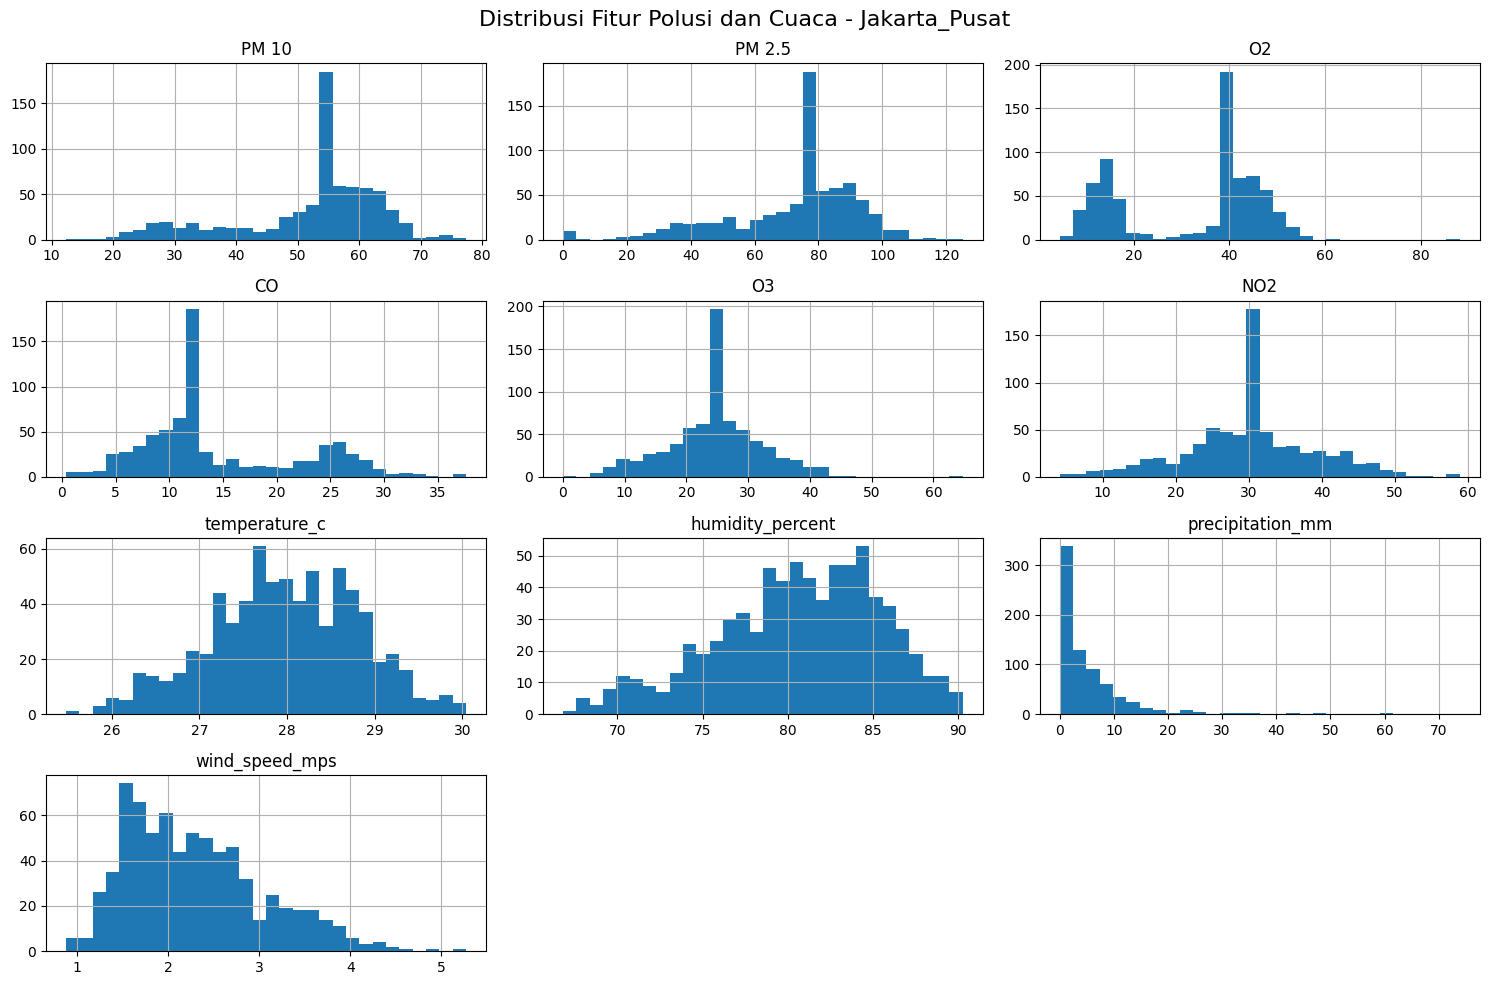


🔹 Korelasi antar Variabel:


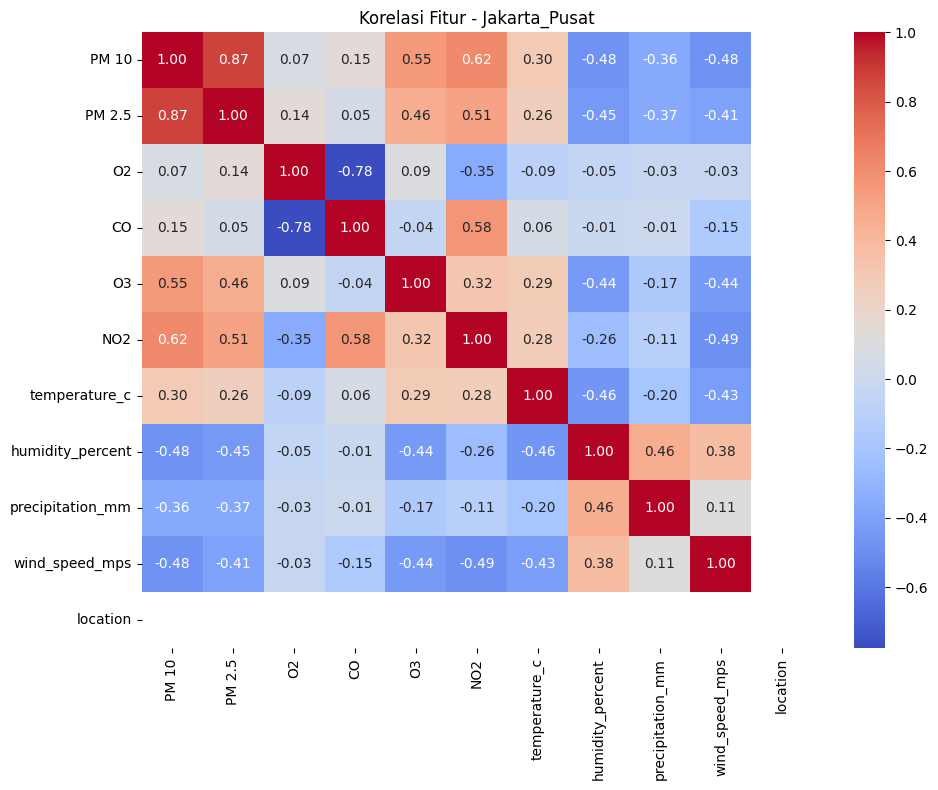


🔹 Tren Waktu untuk PM 2.5:


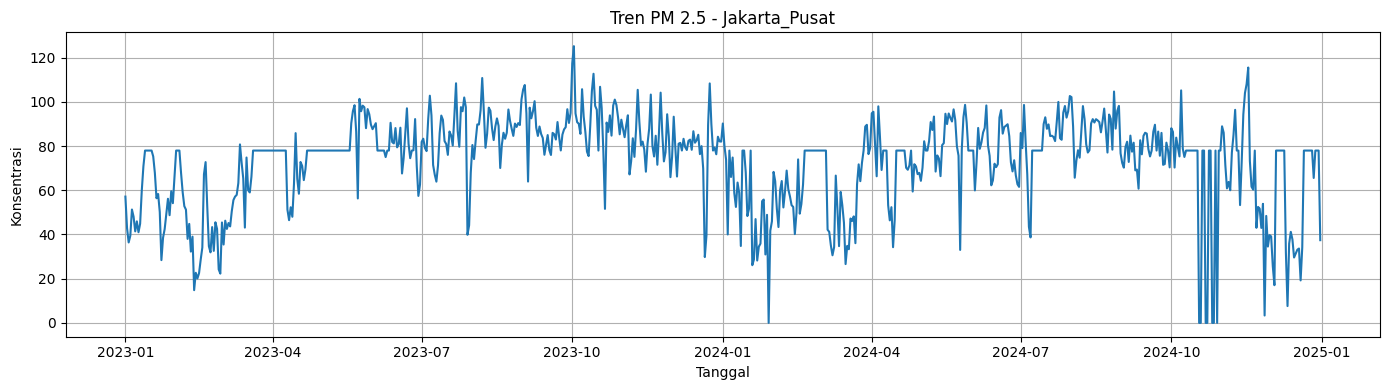


🔹 Boxplot Polutan dan Cuaca:


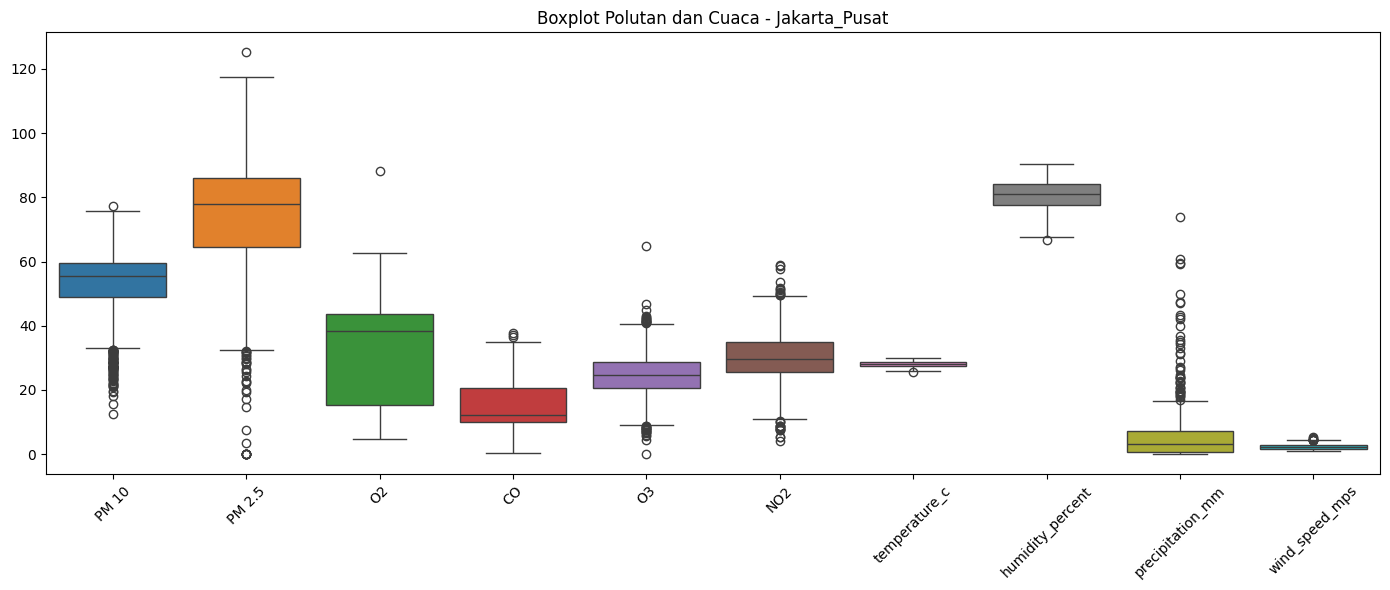


📍 EDA untuk Jakarta_Timur
🔹 Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   temperature_c     731 non-null    float64
 1   humidity_percent  731 non-null    float64
 2   precipitation_mm  731 non-null    float64
 3   wind_speed_mps    731 non-null    float64
 4   PM 10             731 non-null    float64
 5   PM 2.5            731 non-null    float64
 6   O2                731 non-null    float64
 7   CO                731 non-null    float64
 8   O3                731 non-null    float64
 9   NO2               731 non-null    float64
 10  location          731 non-null    int64  
 11  Year              731 non-null    int32  
 12  Month             731 non-null    int32  
 13  Day               731 non-null    int32  
dtypes: float64(10), int32(3), int64(1)
memory usage: 71.5 KB
None

🔹 Deskripsi Statistik:
            

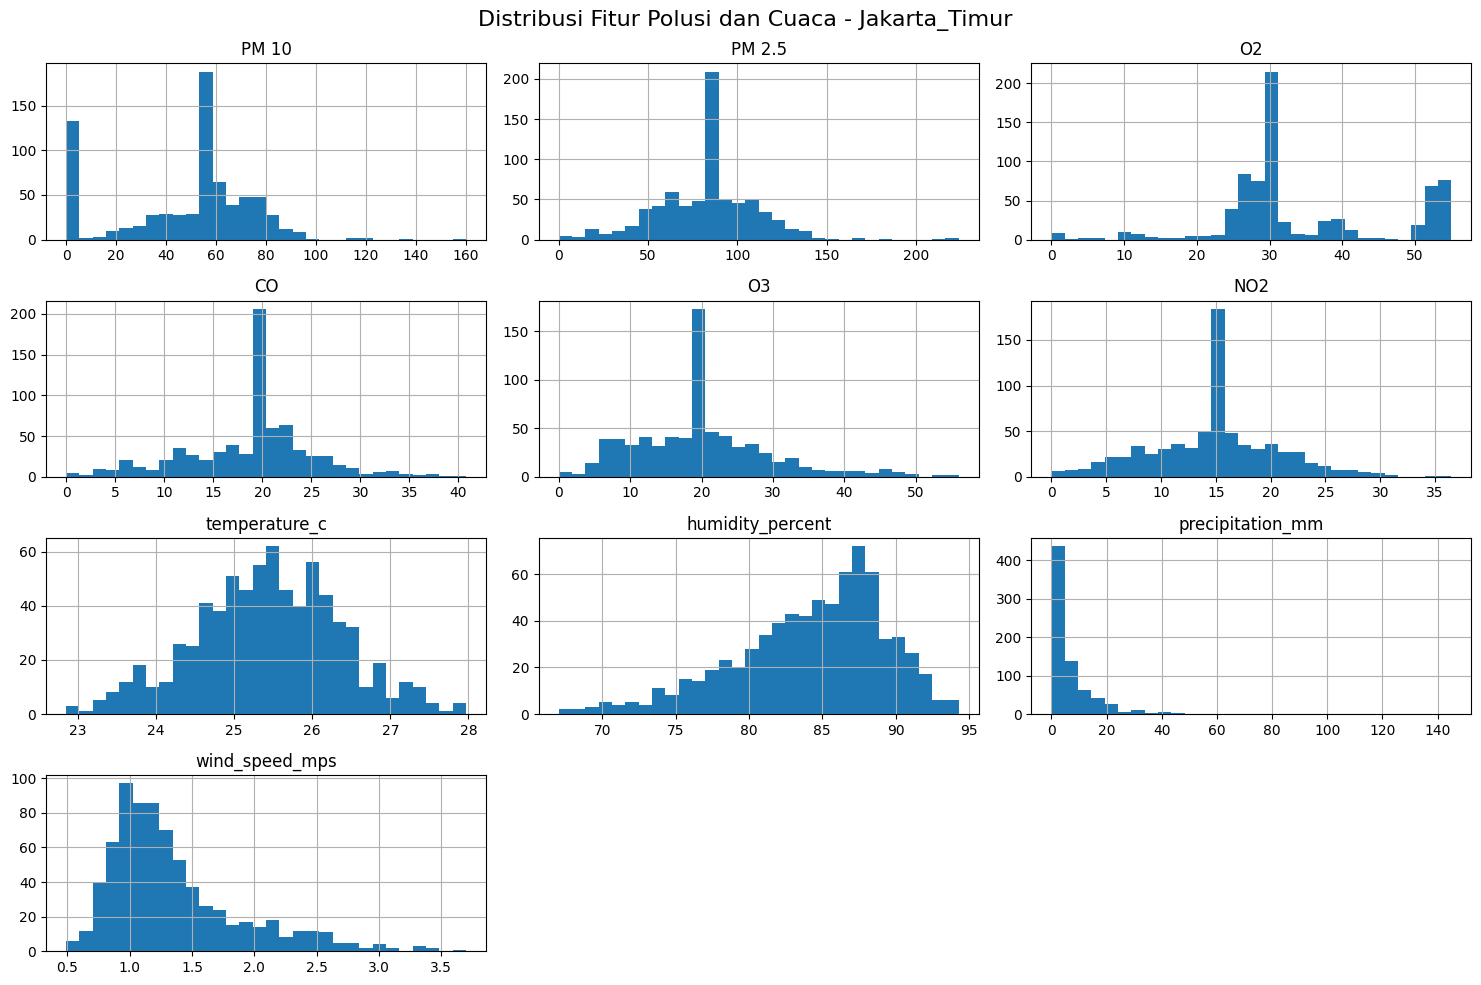


🔹 Korelasi antar Variabel:


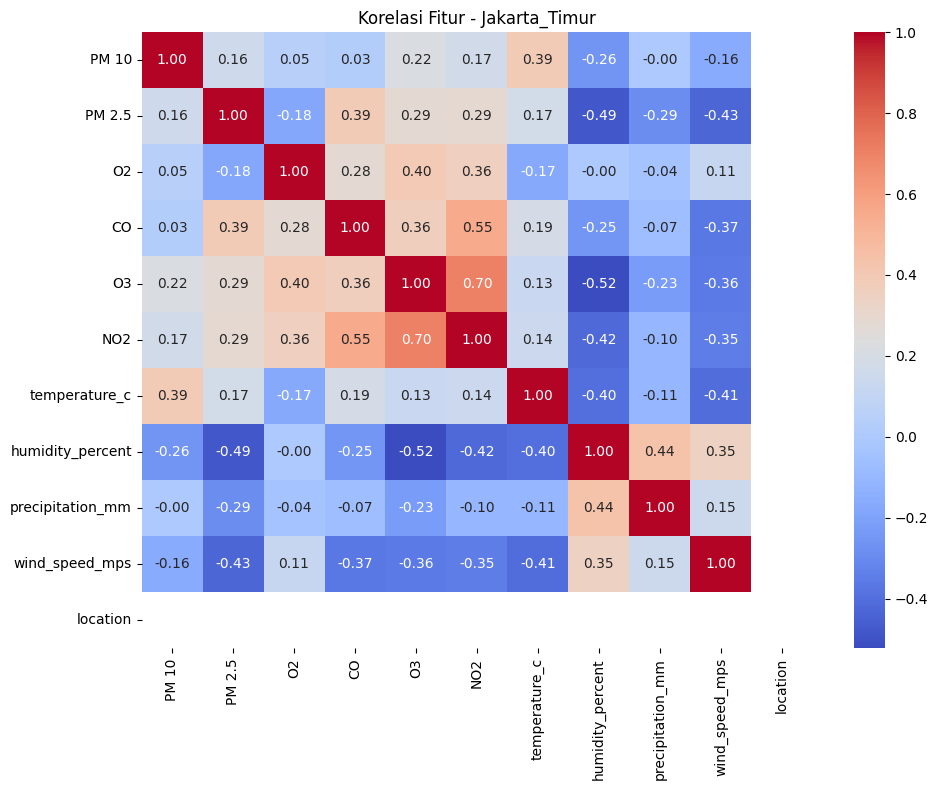


🔹 Tren Waktu untuk PM 2.5:


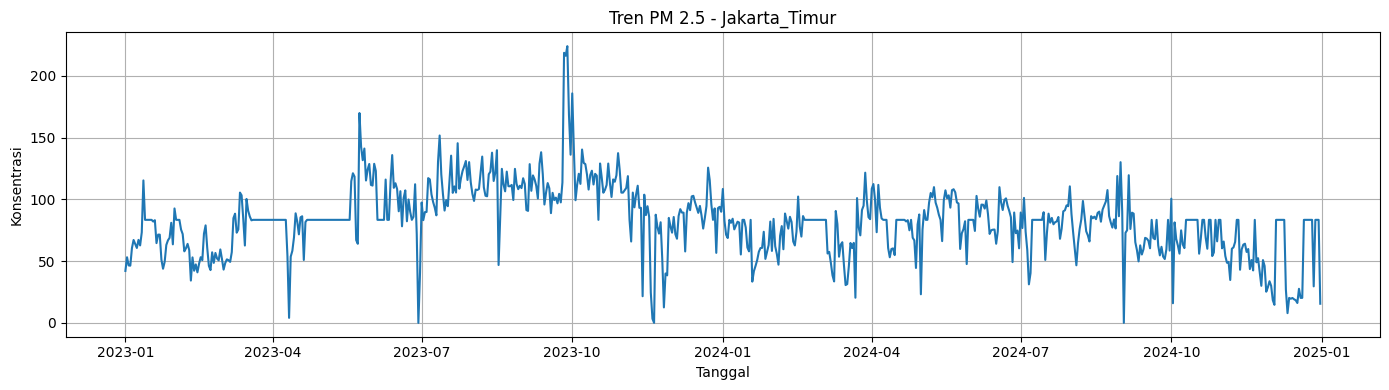


🔹 Boxplot Polutan dan Cuaca:


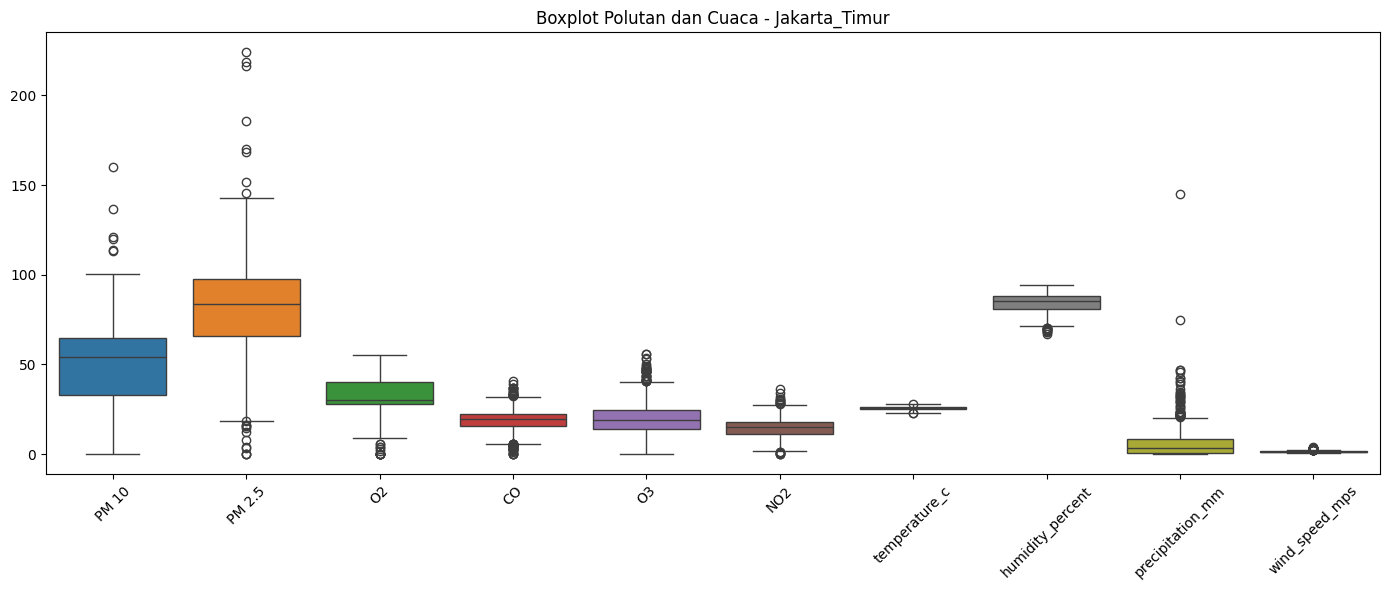


📍 EDA untuk Jakarta_Utara
🔹 Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   temperature_c     731 non-null    float64
 1   humidity_percent  731 non-null    float64
 2   precipitation_mm  731 non-null    float64
 3   wind_speed_mps    731 non-null    float64
 4   PM 10             731 non-null    float64
 5   PM 2.5            731 non-null    float64
 6   O2                731 non-null    float64
 7   CO                731 non-null    float64
 8   O3                731 non-null    float64
 9   NO2               731 non-null    float64
 10  location          731 non-null    int64  
 11  Year              731 non-null    int32  
 12  Month             731 non-null    int32  
 13  Day               731 non-null    int32  
dtypes: float64(10), int32(3), int64(1)
memory usage: 71.5 KB
None

🔹 Deskripsi Statistik:
            

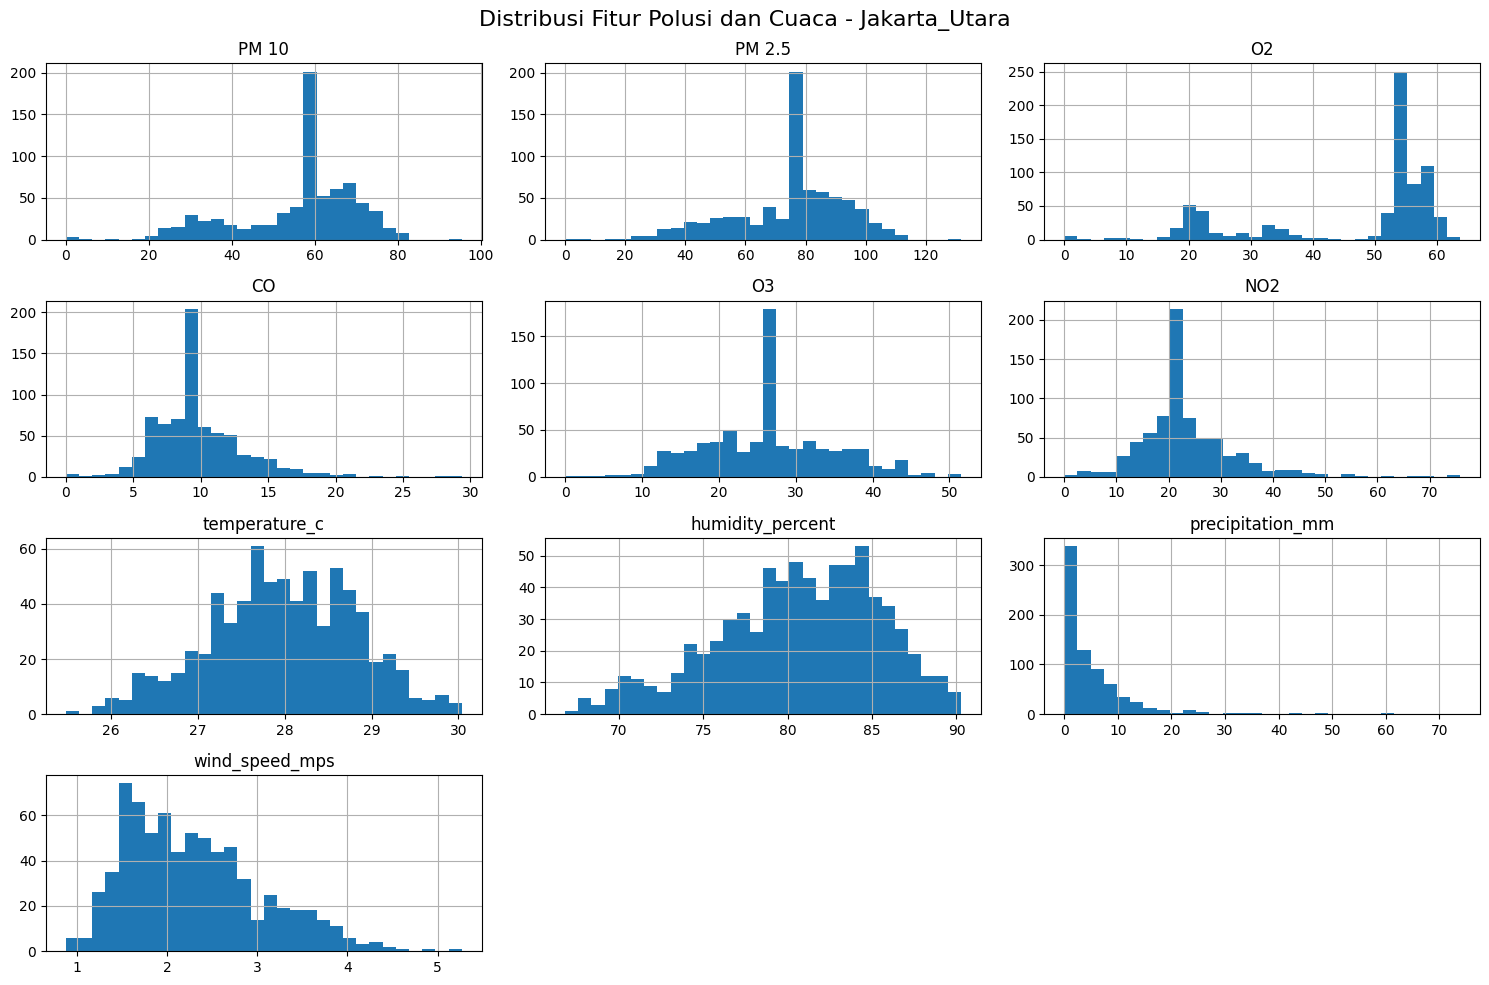


🔹 Korelasi antar Variabel:


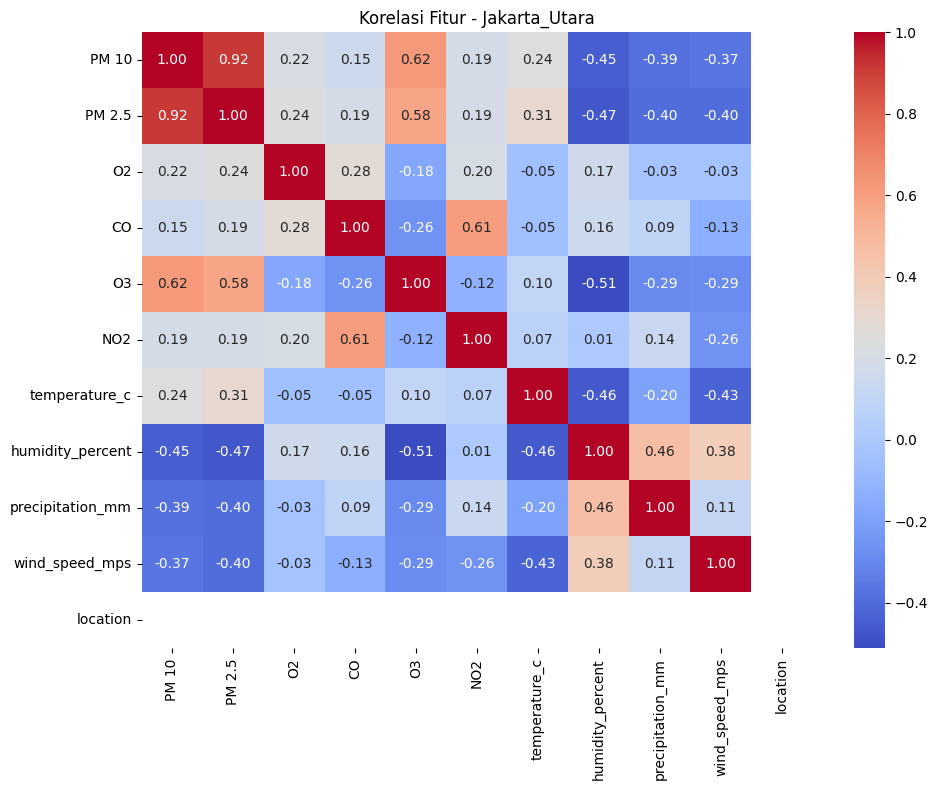


🔹 Tren Waktu untuk PM 2.5:


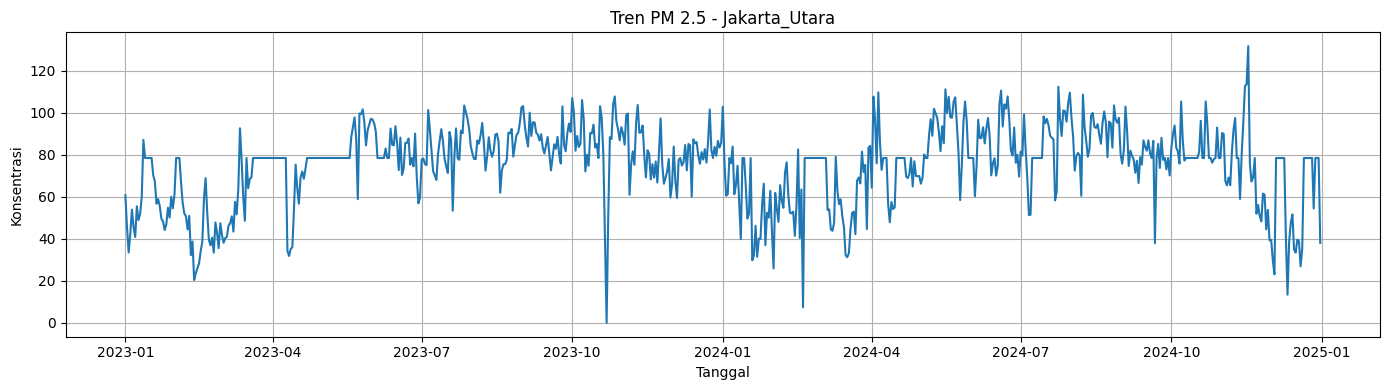


🔹 Boxplot Polutan dan Cuaca:


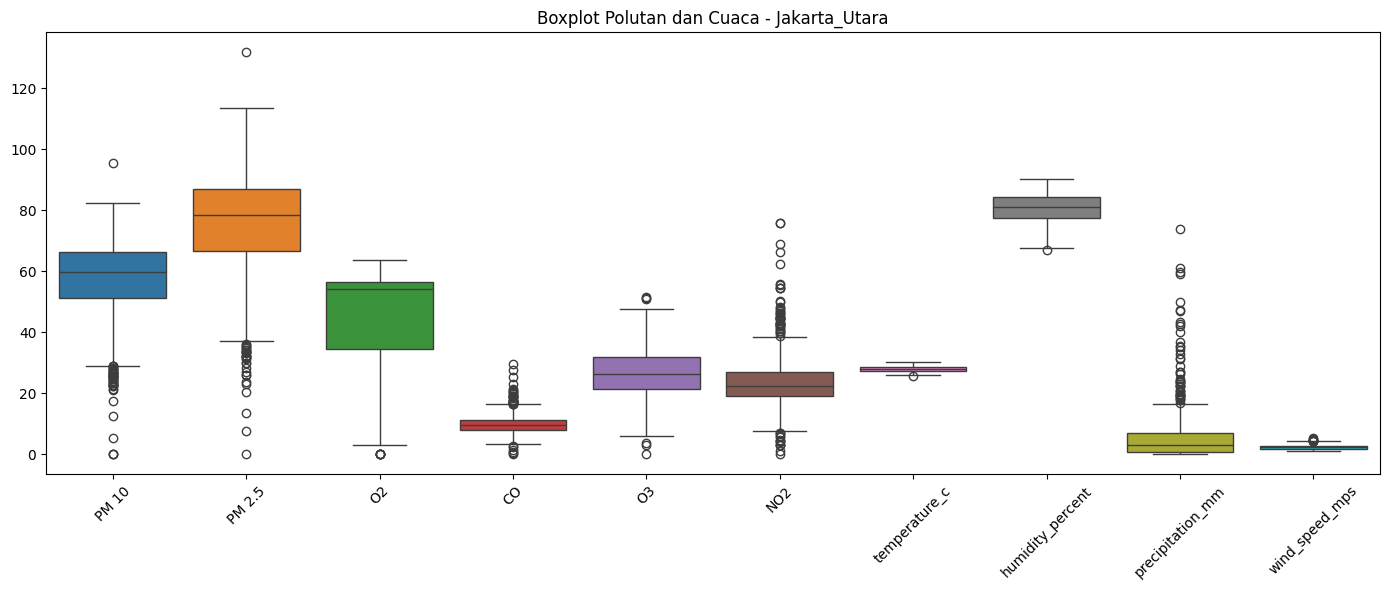


📍 EDA untuk Jakarta_Selatan
🔹 Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   temperature_c     732 non-null    float64
 1   humidity_percent  732 non-null    float64
 2   precipitation_mm  732 non-null    float64
 3   wind_speed_mps    732 non-null    float64
 4   PM 10             732 non-null    float64
 5   PM 2.5            732 non-null    float64
 6   O2                732 non-null    float64
 7   CO                732 non-null    float64
 8   O3                732 non-null    float64
 9   NO2               732 non-null    float64
 10  location          732 non-null    int64  
 11  Year              732 non-null    int32  
 12  Month             732 non-null    int32  
 13  Day               732 non-null    int32  
dtypes: float64(10), int32(3), int64(1)
memory usage: 71.6 KB
None

🔹 Deskripsi Statistik:
          

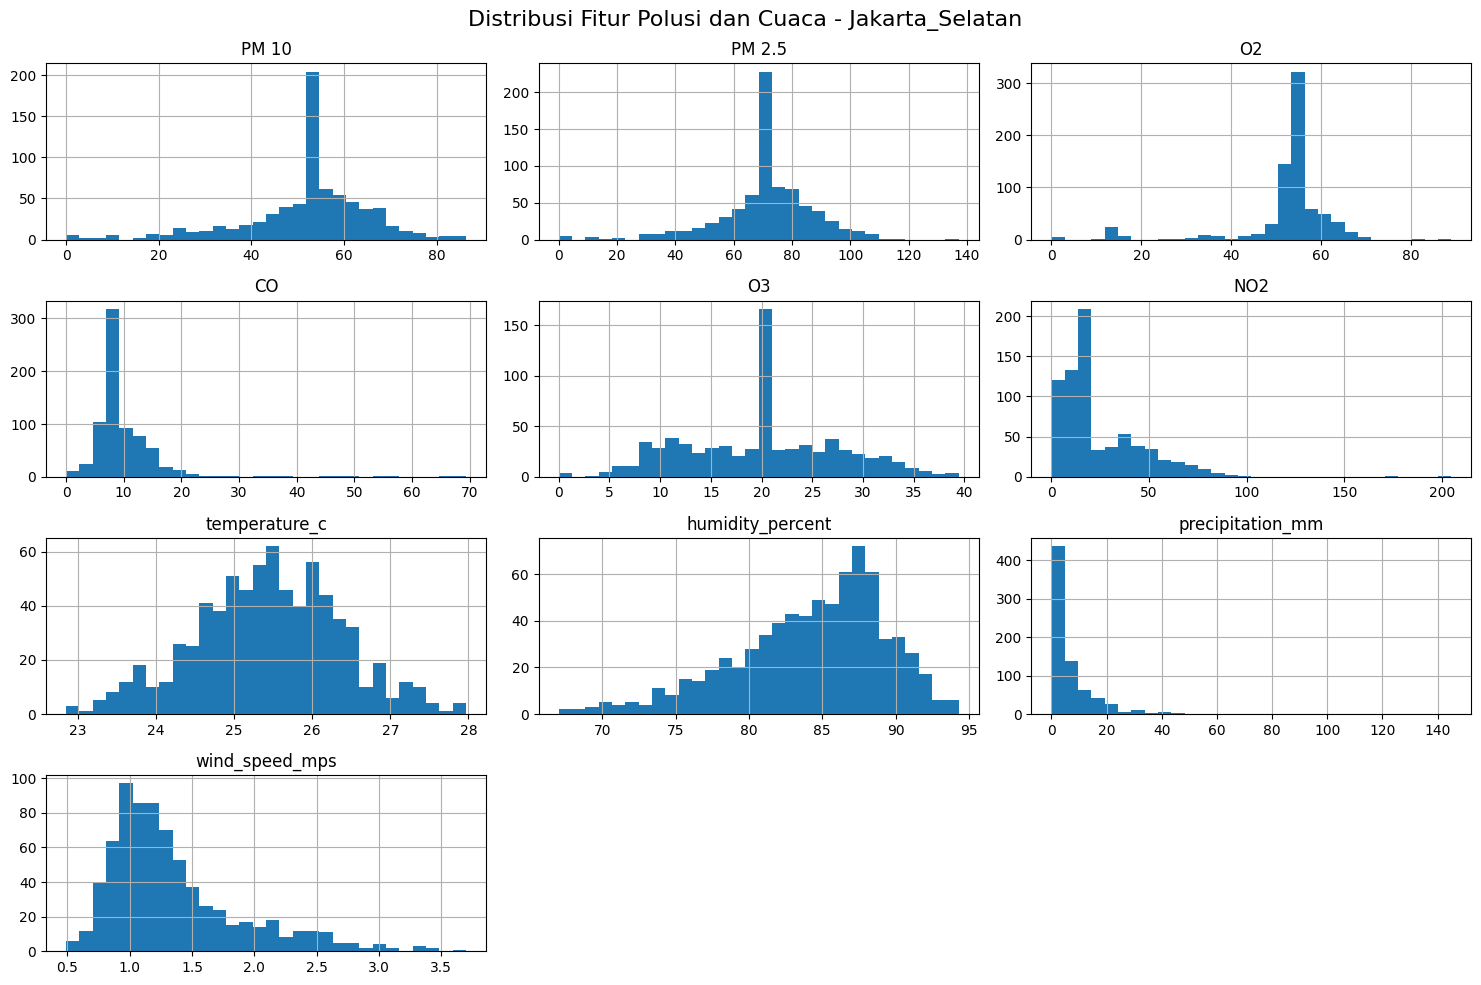


🔹 Korelasi antar Variabel:


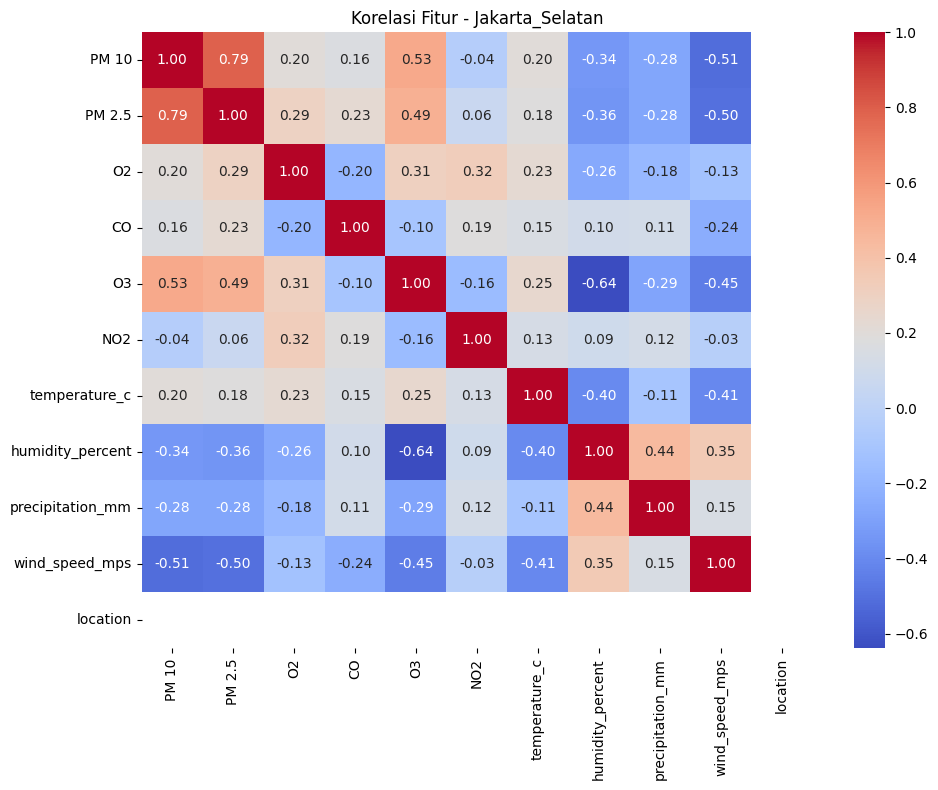


🔹 Tren Waktu untuk PM 2.5:


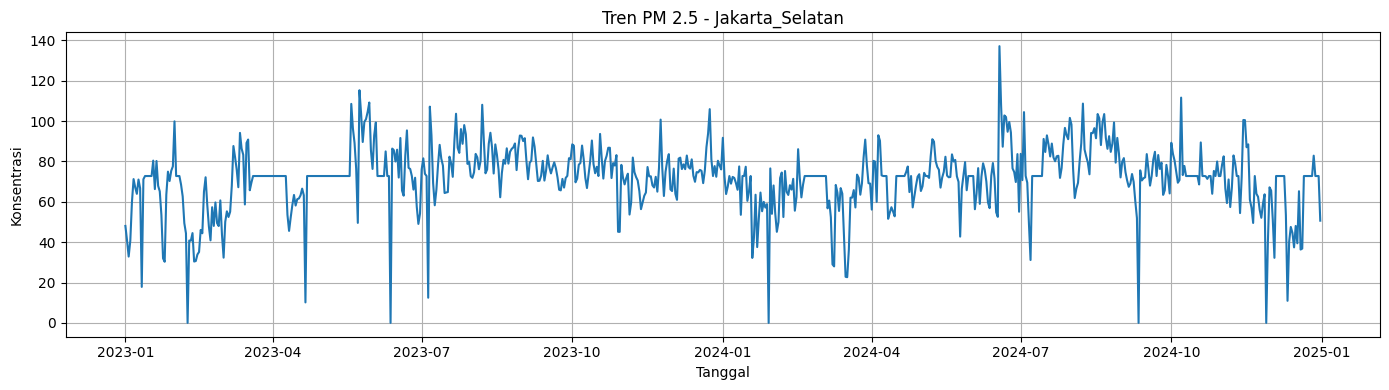


🔹 Boxplot Polutan dan Cuaca:


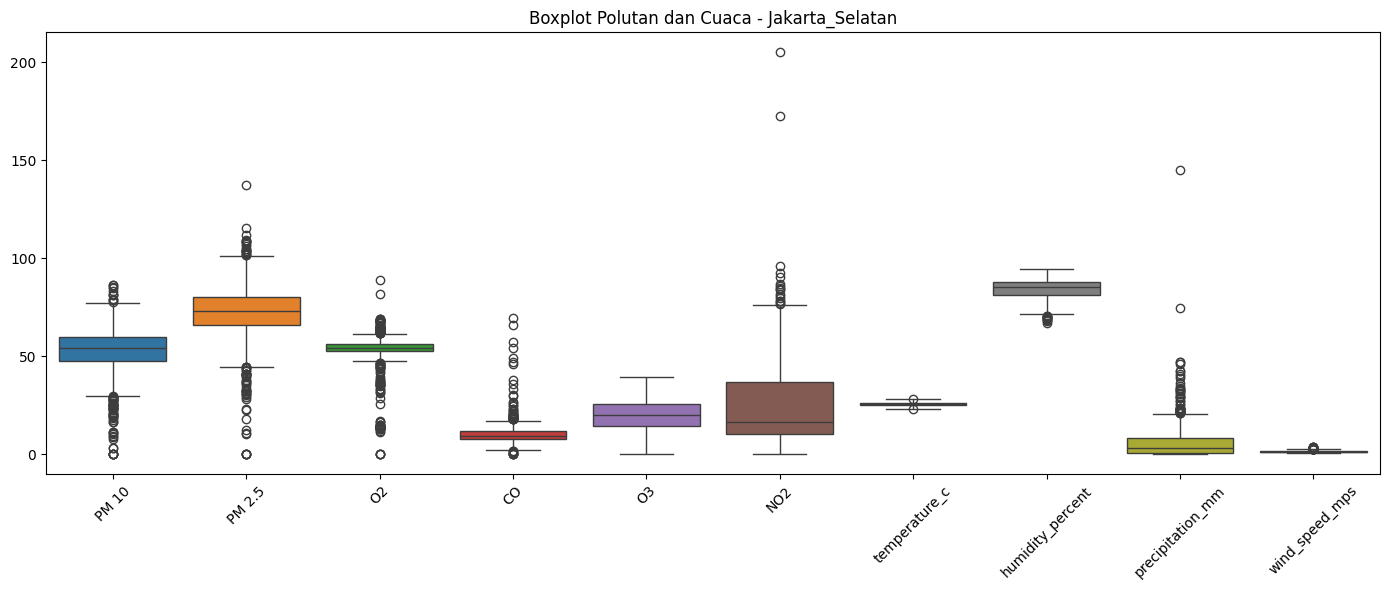


📍 EDA untuk Jakarta_Barat
🔹 Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   temperature_c     731 non-null    float64
 1   humidity_percent  731 non-null    float64
 2   precipitation_mm  731 non-null    float64
 3   wind_speed_mps    731 non-null    float64
 4   PM 10             731 non-null    float64
 5   PM 2.5            731 non-null    float64
 6   O2                731 non-null    float64
 7   CO                731 non-null    float64
 8   O3                731 non-null    float64
 9   NO2               731 non-null    float64
 10  location          731 non-null    int64  
 11  Year              731 non-null    int32  
 12  Month             731 non-null    int32  
 13  Day               731 non-null    int32  
dtypes: float64(10), int32(3), int64(1)
memory usage: 71.5 KB
None

🔹 Deskripsi Statistik:
            

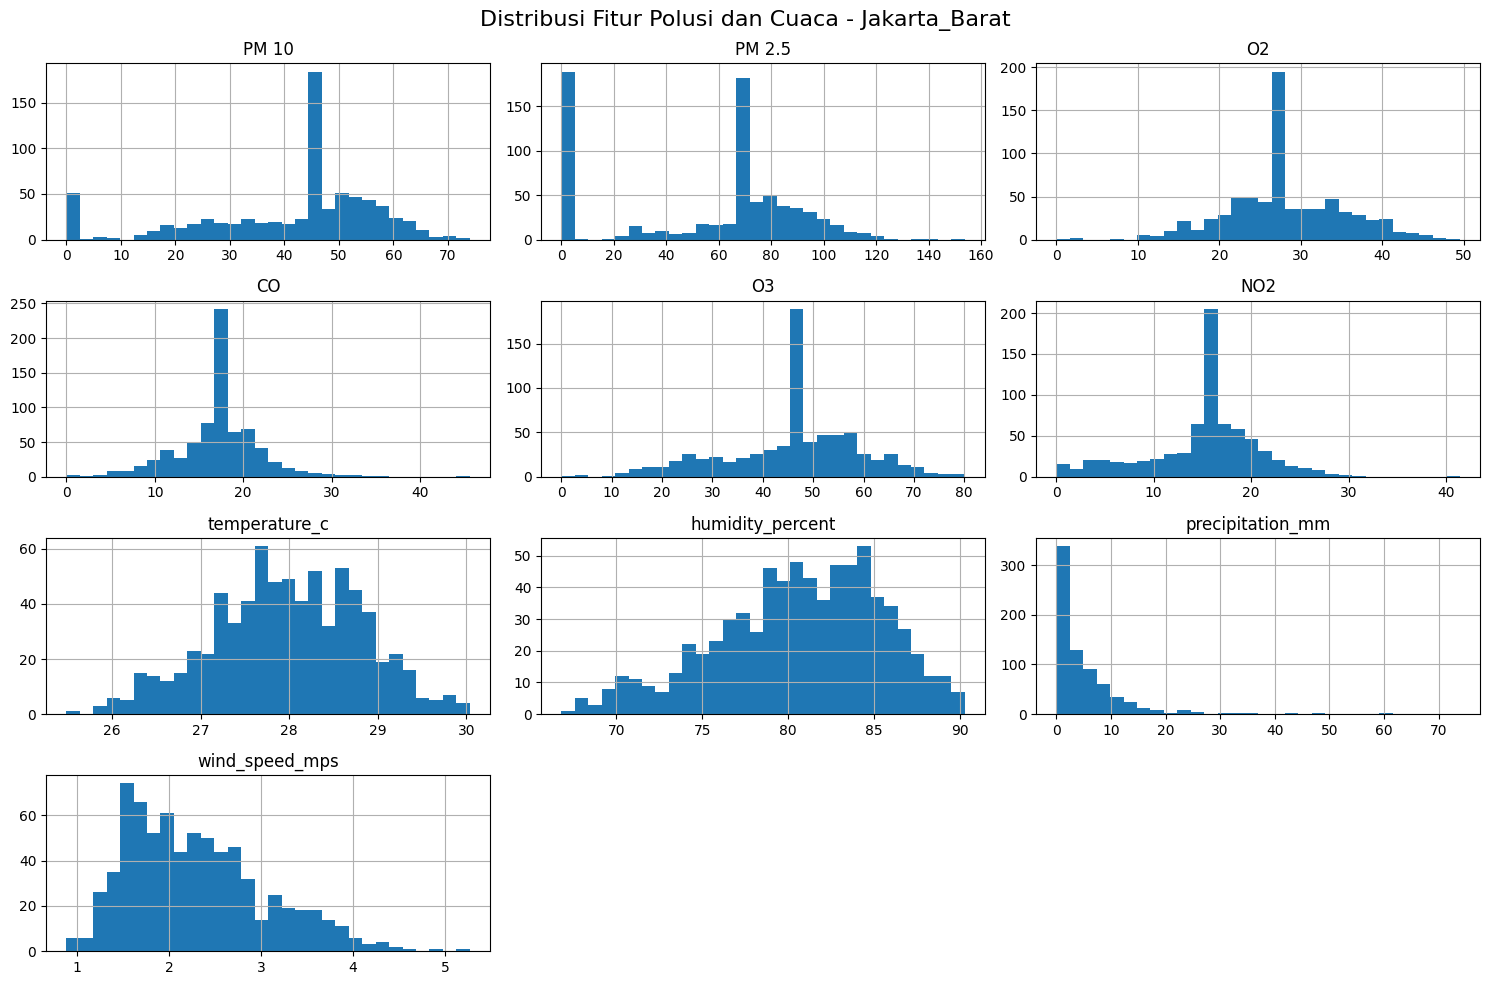


🔹 Korelasi antar Variabel:


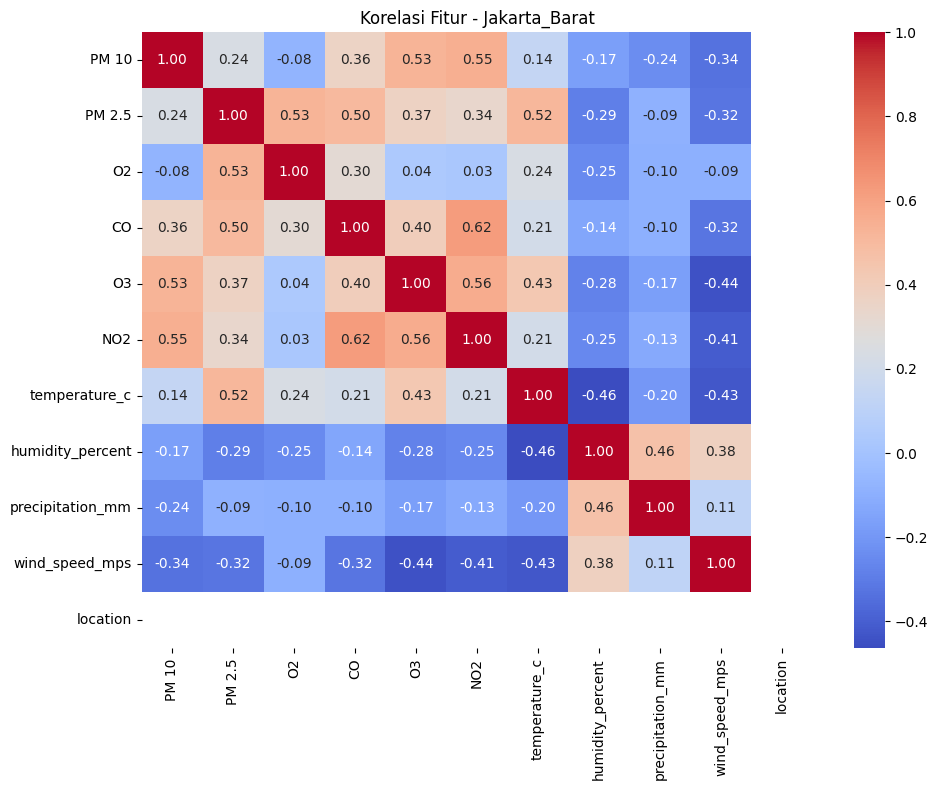


🔹 Tren Waktu untuk PM 2.5:


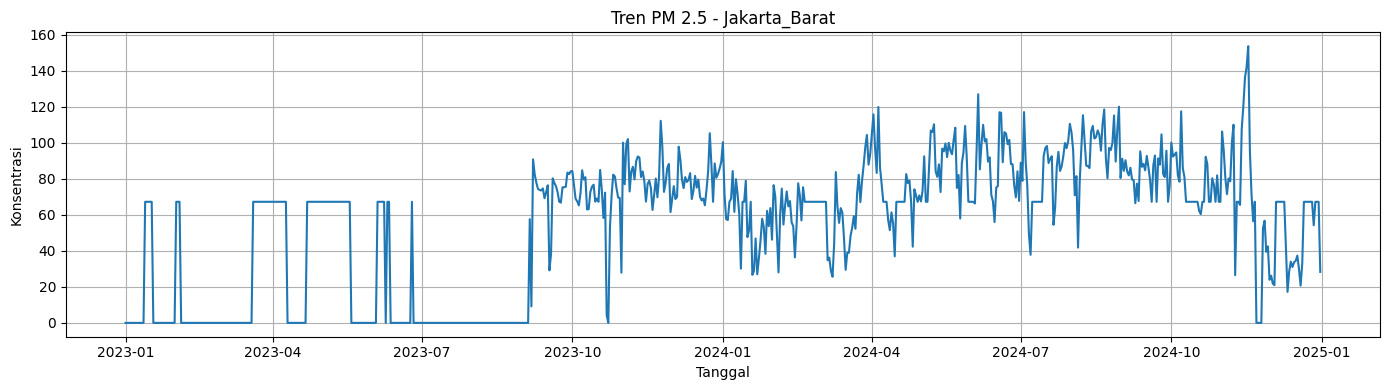


🔹 Boxplot Polutan dan Cuaca:


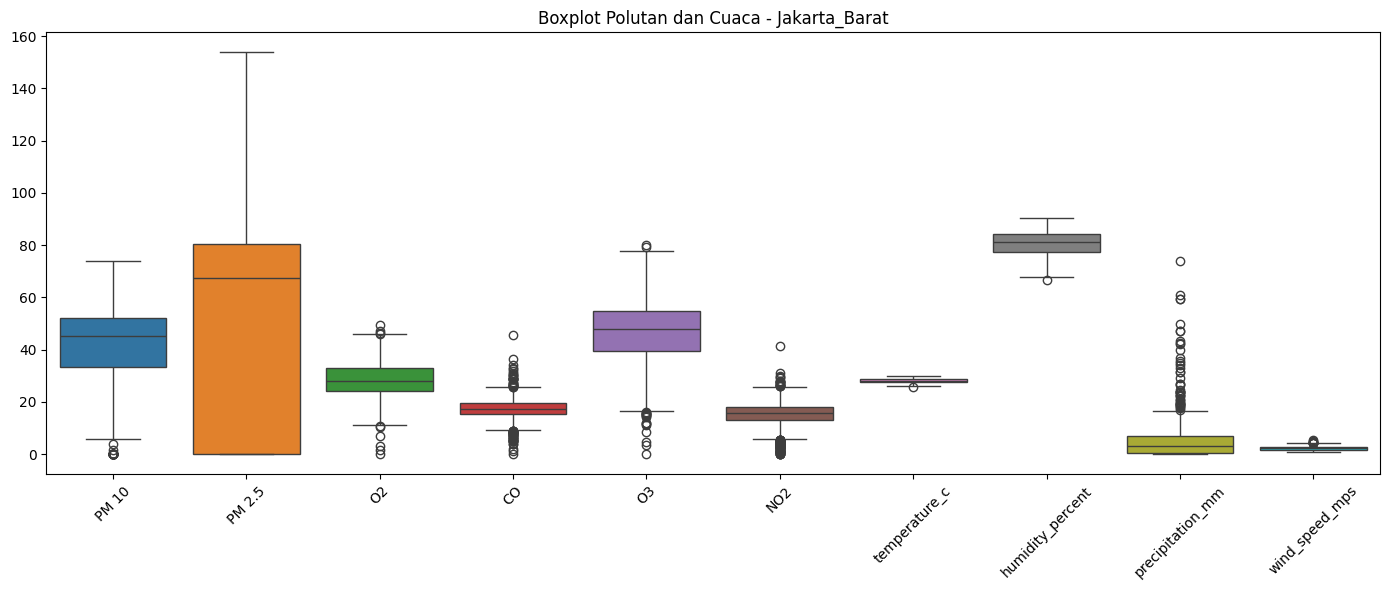

In [87]:
# Function EDA

def eda_summary(preprocessed_data):
    cols_to_plot = ['PM 10', 'PM 2.5', 'O2', 'CO', 'O3', 'NO2', 
                    'temperature_c', 'humidity_percent', 'precipitation_mm', 'wind_speed_mps']
    
    for name, df in preprocessed_data.items():
        print(f"\n📍 EDA untuk {name}")
        print("="*60)

        # Informasi dasar
        print("🔹 Info Data:")
        print(df.info())

        print("\n🔹 Deskripsi Statistik:")
        print(df.describe().T)

        # Cek Missing Values
        print("\n🔹 Missing Values per Kolom:")
        print(df.isnull().sum())

        # Distribusi Data
        print("\n🔹 Distribusi Histogram:")
        df[cols_to_plot].hist(bins=30, figsize=(15, 10))
        plt.suptitle(f"Distribusi Fitur Polusi dan Cuaca - {name}", fontsize=16)
        plt.tight_layout()
        plt.show()

        # Korelasi antar kolom
        print("\n🔹 Korelasi antar Variabel:")
        corr = df[cols_to_plot + ['location']].corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
        plt.title(f"Korelasi Fitur - {name}")
        plt.tight_layout()
        plt.show()

        # Time series PM 2.5
        print("\n🔹 Tren Waktu untuk PM 2.5:")
        df['ds'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
        plt.figure(figsize=(14, 4))
        plt.plot(df['ds'], df['PM 2.5'], label='PM 2.5')
        plt.title(f"Tren PM 2.5 - {name}")
        plt.xlabel("Tanggal")
        plt.ylabel("Konsentrasi")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Boxplot
        print("\n🔹 Boxplot Polutan dan Cuaca:")
        plt.figure(figsize=(14, 6))
        sns.boxplot(data=df[cols_to_plot])
        plt.title(f"Boxplot Polutan dan Cuaca - {name}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        print("="*60)

# Contoh pemanggilan
eda_summary(preprocessed_data)


# Feature Engine

## Train, Val, and Test Data

In [17]:
# Rasio split
train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

# Kolom fitur dan target
target_column = 'PM 2.5'
feature_columns = [col for col in df.columns if col != target_column]

# Dictionary untuk menyimpan hasil split per lokasi
splits = {}

for location, df in preprocessed_data.items():
    # Urutkan data berdasarkan waktu
    df_sorted = df.sort_values(by=["Year", "Month", "Day"]).reset_index(drop=True)

    total = len(df_sorted)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    # Split data
    train = df_sorted.iloc[:train_end]
    val = df_sorted.iloc[train_end:val_end]
    test = df_sorted.iloc[val_end:]

    # Pisahkan fitur dan target
    X_train, y_train = train[feature_columns], train[target_column]
    X_val, y_val = val[feature_columns], val[target_column]
    X_test, y_test = test[feature_columns], test[target_column]

    # Simpan hasil
    splits[location] = {
        "X_train": X_train, "y_train": y_train,
        "X_val": X_val, "y_val": y_val,
        "X_test": X_test, "y_test": y_test,
    }

    print(f"✅ Split selesai untuk {location}: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

✅ Split selesai untuk Jakarta_Pusat: Train=511, Val=146, Test=74
✅ Split selesai untuk Jakarta_Timur: Train=511, Val=146, Test=74
✅ Split selesai untuk Jakarta_Utara: Train=511, Val=146, Test=74
✅ Split selesai untuk Jakarta_Selatan: Train=512, Val=146, Test=74
✅ Split selesai untuk Jakarta_Barat: Train=511, Val=146, Test=74


In [18]:
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
X_val.reset_index(drop=True, inplace=True)
y_val.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

In [19]:
# Jika y dalam bentuk array

y_train = np.where(np.isnan(y_train), np.nanmedian(y_train), y_train)
y_val = np.where(np.isnan(y_val), np.nanmedian(y_val), y_val)
y_test = np.where(np.isnan(y_test), np.nanmedian(y_test), y_test)

In [20]:
# Daftar semua kolom fitur numerik (kecuali target 'PM 2.5')
num_cols = [col for col in df.columns if col != 'PM 2.5']
low_var_cols = [col for col in num_cols if X_train[col].std() < 0.01]
num_cols = [col for col in num_cols if col not in low_var_cols]

# Pipeline

In [21]:
# Pipeline untuk kolom numerik
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('winsorizer', Winsorizer(capping_method='iqr', tail='both', fold=1.5)),
    ('scaler', MinMaxScaler())
])

# Column transformer akhir (hanya numerik)
final_pipeline = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols)
    ]
)

In [22]:
# application pipeline data processing

X_train = final_pipeline.fit_transform(X_train)
X_val = final_pipeline.transform(X_val)
X_test = final_pipeline.transform(X_test)

In [23]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (511, 12)
X_val shape: (146, 12)
X_test shape: (74, 12)


In [24]:
# Input Data Pipeline

train_pipe = tf.data.Dataset.from_tensor_slices((X_train,y_train)).batch(32).prefetch(tf.data.AUTOTUNE)
test_pipe = tf.data.Dataset.from_tensor_slices((X_test,y_test)).batch(32)
val_pipe = tf.data.Dataset.from_tensor_slices((X_val,y_val)).batch(32)

2025-05-06 07:41:13.175549: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# Modeling

## Hybrid ES-RNN

### Model Definition

In [25]:
# 1️⃣ Exponential Smoothing (ES) untuk Menangkap Tren & Musiman
def apply_exponential_smoothing(series, trend="add", seasonal="add", seasonal_periods=12):
    model_es = ExponentialSmoothing(series, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods)
    fitted_model = model_es.fit()
    return fitted_model.fittedvalues, fitted_model.forecast(steps=30)

# 2️⃣ Membangun Model LSTM untuk Menangkap Pola Non-Linear
model_es_rnn = Sequential([
    LSTM(64, return_sequences=True, input_shape=(30, 1)),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(32),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1)
])

# 3️⃣ Kompilasi Model
model_es_rnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse", metrics=['mae'])

# 4️⃣ Tampilkan Struktur Model
model_es_rnn.summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,729 (116.13 KB)

 Trainable params: 29,537 (115.38 KB)

 Non-trainable params: 192 (768.00 B)

### Model Training

In [35]:
# Define erlystopping

early_stopping = EarlyStopping(
    monitor='loss',
    patience=10,
    mode='auto',
    baseline=None,
    restore_best_weights=True,
)

In [27]:
# Training Model


history_hybrid = model_es_rnn.fit(train_pipe,
                                   epochs=100,
                                   validation_data=(val_pipe),
                                   batch_size=30,
                                   callbacks=[early_stopping])

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 1496.4631 - mae: 24.6564 - val_loss: 8274.2490 - val_mae: 89.8075
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1439.3308 - mae: 24.6196 - val_loss: 8259.3994 - val_mae: 89.7266
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1423.2449 - mae: 24.8659 - val_loss: 8261.4717 - val_mae: 89.7398
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1409.8619 - mae: 25.0298 - val_loss: 8261.7412 - val_mae: 89.7431
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1396.6035 - mae: 25.2460 - val_loss: 8265.6182 - val_mae: 89.7666
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1388.6919 - mae: 25.1911 - val_loss: 8266.9375 - val_mae: 89.7761
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1376.2061 - mae: 25.2053 - val_loss: 8265.9326 - val_mae: 89.7730
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1355.8948 - mae: 25.2228 - val_loss: 8246.2607 - val_mae: 89.6669

### Model Evaluation

In [28]:
# Make result of training model to data frame

history_esrnn_df = pd.DataFrame(history_hybrid.history)

<Axes: >

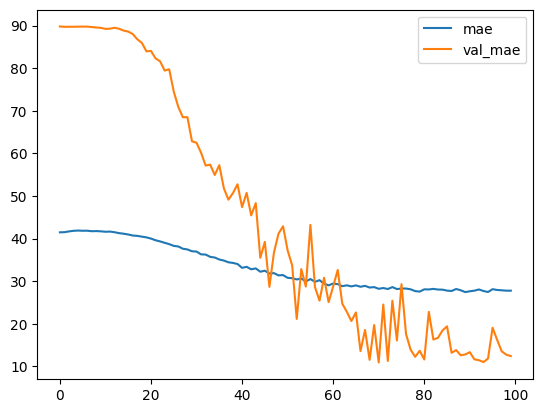

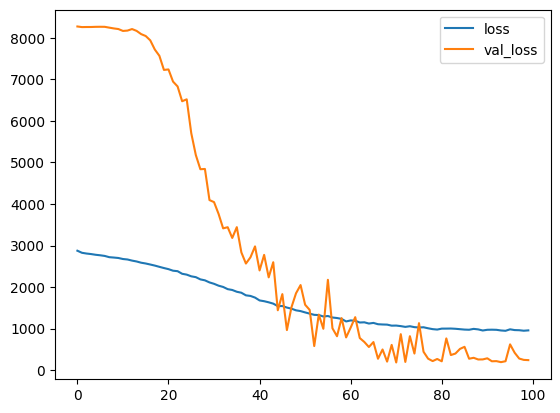

In [29]:
# Show in Plot grafik about the result

history_esrnn_df[['mae', 'val_mae']].plot()
history_esrnn_df[['loss', 'val_loss']].plot()

In [30]:
# 1️⃣ Pastikan jumlah y_pred sesuai dengan y_test
y_pred = model_es_rnn.predict(X_test)

# 2️⃣ Hitung Metrik Evaluasi
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / np.maximum(y_test, 1e-10))) * 100  

# 3️⃣ Tampilkan Hasil Evaluasi
print(f"🔹 Evaluasi Model Hybrid ES-RNN:")
print(f"   ✅ MAE  : {mae:.4f}")
print(f"   ✅ MSE  : {mse:.4f}")
print(f"   ✅ RMSE : {rmse:.4f}")
print(f"   ✅ MAPE : {mape:.4f}%")


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
🔹 Evaluasi Model Hybrid ES-RNN:
   ✅ MAE  : 20.1486
   ✅ MSE  : 618.3494
   ✅ RMSE : 24.8666
   ✅ MAPE : 3767396665012.9668%


### Tuning

In [31]:
def build_model(hp):
    model = Sequential()

    # LSTM Layer 1
    model.add(LSTM(
        units=hp.Int("units_lstm1", min_value=32, max_value=128, step=16),
        return_sequences=True,
        input_shape=(30, 1)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout1", 0.1, 0.5, step=0.1)))

    # LSTM Layer 2
    model.add(LSTM(
        units=hp.Int("units_lstm2", min_value=16, max_value=64, step=16),
        return_sequences=False
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout2", 0.1, 0.5, step=0.1)))

    # Dense output
    model.add(Dense(1))

    # Compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model


In [33]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=10,              # Jumlah kombinasi yang dicoba
    executions_per_trial=1,     # Bisa ditingkatkan untuk rata-rata hasil
    directory="tuning_dir",
    project_name="hybrid_es_rnn"
)

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [34]:
tuner.search(train_pipe,
             epochs=50,
             validation_data=val_pipe,
             callbacks=[early_stopping])

Trial 10 Complete [00h 00m 16s]
val_loss: 243.0157012939453

Best val_loss So Far: 151.1031951904297
Total elapsed time: 00h 05m 21s


In [37]:
# 1️⃣ Ambil model dengan performa terbaik dari hasil tuning
best_model = tuner.get_best_models(num_models=1)[0]

# 2️⃣ Kompilasi ulang model (opsional tapi disarankan, terutama jika ada perubahan custom metric atau callback)
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# 3️⃣ Latih ulang model dengan data training dan validasi secara penuh
history_tune = best_model.fit(
    train_pipe,
    epochs=100,  # jumlah epoch penuh
    validation_data=val_pipe,
    callbacks=[early_stopping]  # jika Anda menggunakan EarlyStopping
)

Epoch 1/100


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 966.1307 - mae: 28.3115 - val_loss: 198.3168 - val_mae: 10.9032
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 929.6746 - mae: 28.1657 - val_loss: 218.7641 - val_mae: 11.6181
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 916.2551 - mae: 27.9063 - val_loss: 210.5448 - val_mae: 11.2139
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 917.4528 - mae: 28.0304 - val_loss: 254.3988 - val_mae: 12.2992
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 910.6070 - mae: 27.8243 - val_loss: 250.9511 - val_mae: 12.3641
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 912.9356 - mae: 27.8408 - val_loss: 428.3633 - val_mae: 16.8492
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 916.5770 - mae: 27.9756 - val_loss: 533.1597 - val_mae: 18.8592
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 901.2711 - mae: 27.8397 - val_loss: 629.4436 - val_mae: 21.2652
Epoch 9/100
16/16 ━━

In [38]:
# Make result of training model to data frame

history_tune_df = pd.DataFrame(history_tune.history)

<Axes: >

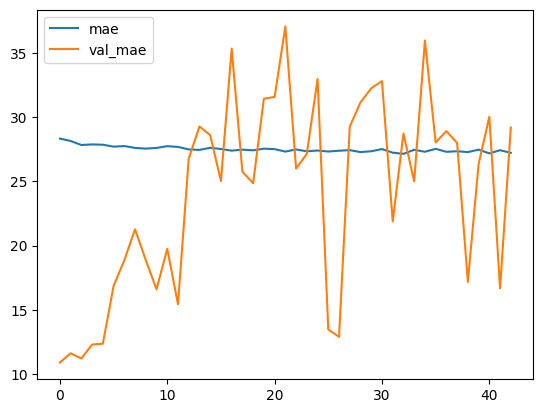

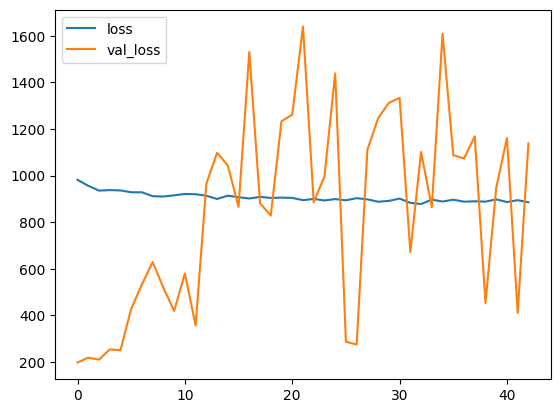

In [39]:
# Show in Plot grafik about the result

history_tune_df[['mae', 'val_mae']].plot()
history_tune_df[['loss', 'val_loss']].plot()

In [40]:
# 1️⃣ Pastikan jumlah y_pred sesuai dengan y_test
y_pred_tune = best_model.predict(X_test)

# 2️⃣ Hitung Metrik Evaluasi
mae_tune = mean_absolute_error(y_test, y_pred_tune)
mse_tune = mean_squared_error(y_test, y_pred_tune)
rmse_tune = np.sqrt(mse)
mape_tune = np.mean(np.abs((y_test - y_pred_tune) / np.maximum(y_test, 1e-10))) * 100  

# 3️⃣ Tampilkan Hasil Evaluasi
print(f"🔹 Evaluasi Model Hybrid ES-RNN:")
print(f"   ✅ MAE  : {mae_tune:.4f}")
print(f"   ✅ MSE  : {mse_tune:.4f}")
print(f"   ✅ RMSE : {rmse_tune:.4f}")
print(f"   ✅ MAPE : {mape_tune:.4f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step
🔹 Evaluasi Model Hybrid ES-RNN:
   ✅ MAE  : 56.1517
   ✅ MSE  : 3888.1405
   ✅ RMSE : 24.8666
   ✅ MAPE : 6121015260435.0762%


## LSTM

### Model Definition

In [55]:
# Clear Session

seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

In [42]:
# 1. Membuat model LSTM
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(10, 1)),  # 10 timesteps, 1 feature
    Dropout(0.2),
    BatchNormalization(),
    LSTM(32),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1)  # Output 1 nilai (regresi time series)
])

# 2. Kompilasi model
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# 3. Tampilkan arsitektur model
model_lstm.summary()


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,729 (116.13 KB)

 Trainable params: 29,537 (115.38 KB)

 Non-trainable params: 192 (768.00 B)

### Model Training

In [43]:
# Define erlystopping

early_stopping = EarlyStopping(
    monitor='loss',
    patience=10,
    mode='auto',
    baseline=None,
    restore_best_weights=True,
)

In [45]:
# Training Model


history_lstm = model_lstm.fit(train_pipe,
                                   epochs=100,
                                   validation_data=(val_pipe),
                                   batch_size=30,
                                   callbacks=[early_stopping])

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 843.6594 - mae: 25.8856 - val_loss: 636.2239 - val_mae: 21.0424
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 838.4346 - mae: 25.7977 - val_loss: 329.4363 - val_mae: 14.6826
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 847.1782 - mae: 25.6716 - val_loss: 655.2125 - val_mae: 21.3912
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 865.8178 - mae: 26.3223 - val_loss: 524.7866 - val_mae: 19.3505
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 838.0869 - mae: 25.8737 - val_loss: 390.0591 - val_mae: 16.4549
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 881.7114 - mae: 26.2418 - val_loss: 440.1614 - val_mae: 17.3006
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 880.5886 - mae: 26.5067 - val_loss: 235.1302 - val_mae: 12.5087
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 864.7993 - mae: 26.5462 - val_loss: 520.9872 - val_mae: 18.5845
Epoch 9/100
16/1

### Model Evaluation

In [46]:
# Make result of training model to data frame

history_lstm_df = pd.DataFrame(history_lstm.history)

<Axes: >

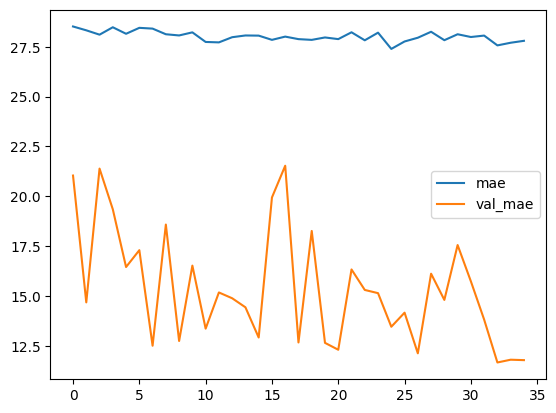

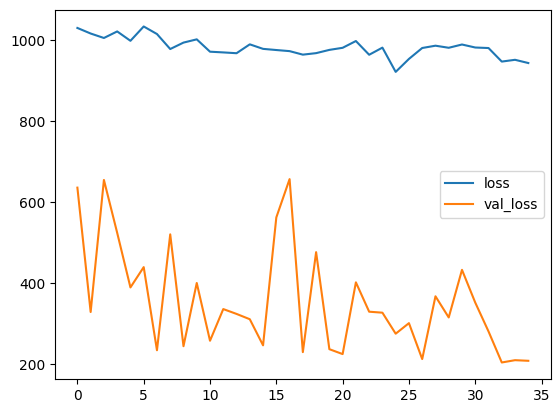

In [47]:
# Show in Plot grafik about the result

history_lstm_df[['mae', 'val_mae']].plot()
history_lstm_df[['loss', 'val_loss']].plot()

In [49]:
# Melakukan prediksi pada test set
y_pred_lstm = model_lstm.predict(X_test)

# Hitung MAE, MSE, RMSE
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
mse_lstm = mean_squared_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mse)

# Tampilkan hasil evaluasi
print(f"Mean Absolute Error (MAE) LSTM: {mae_lstm:.4f}")
print(f"Mean Squared Error (MSE) LSTM: {mse_lstm:.4f}")
print(f"Root Mean Squared Error (RMSE) LSTM: {rmse_lstm:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Mean Absolute Error (MAE) LSTM: 14.9717
Mean Squared Error (MSE) LSTM: 458.5783
Root Mean Squared Error (RMSE) LSTM: 24.8666


## GRU

### Model Definition

In [56]:
# Membangun Model GRU
model_gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(10, 1)),  # 10 timesteps, 1 feature
    BatchNormalization(),
    Dropout(0.2),
    BatchNormalization(),
    GRU(32),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1)
])

# Kompilasi Model
model_gru.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Tampilkan Struktur Model
model_gru.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 10, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,945 (89.63 KB)

 Trainable params: 22,625 (88.38 KB)

 Non-trainable params: 320 (1.25 KB)

### Model Training

In [57]:
# Define erlystopping

early_stopping = EarlyStopping(
    monitor='loss',
    patience=10,
    mode='auto',
    baseline=None,
    restore_best_weights=True,
)

In [58]:
# Training Model

history_gru = model_gru.fit(train_pipe,
                                   epochs=100,
                                   validation_data=(val_pipe),
                                   batch_size=30,
                                   callbacks=[early_stopping])

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 1462.7426 - mae: 24.5196 - val_loss: 8272.5527 - val_mae: 89.8003
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1416.6871 - mae: 24.9469 - val_loss: 8289.9980 - val_mae: 89.9004
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1400.0627 - mae: 25.0380 - val_loss: 8327.2881 - val_mae: 90.1106
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1384.0642 - mae: 25.0280 - val_loss: 8364.1357 - val_mae: 90.3183
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1373.7429 - mae: 25.1957 - val_loss: 8407.4053 - val_mae: 90.5606
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1367.6705 - mae: 25.1889 - val_loss: 8416.5586 - val_mae: 90.6167
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1359.7288 - mae: 25.1471 - val_loss: 8427.7324 - val_mae: 90.6859
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1340.0732 - mae: 25.1731 - val_loss: 8477.3984 - val_mae: 90

### Model Evaluation

In [59]:
# Make result of training model to data frame

history_gru_df = pd.DataFrame(history_gru.history)

<Axes: >

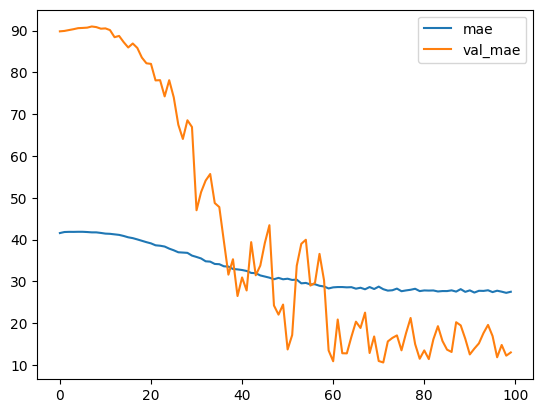

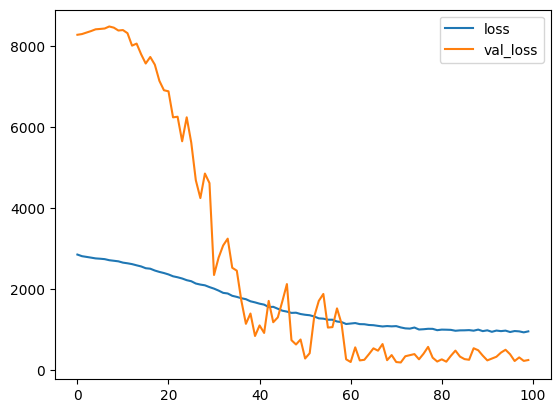

In [60]:
# Show in Plot grafik about the result

history_gru_df[['mae', 'val_mae']].plot()
history_gru_df[['loss', 'val_loss']].plot()

In [61]:
# Melakukan prediksi pada test set
y_pred_gru = model_gru.predict(X_test)

# Hitung MAE, MSE, RMSE
mae_gru = mean_absolute_error(y_test, y_pred_gru)
mse_gru = mean_squared_error(y_test, y_pred_gru)
rmse_gru = np.sqrt(mse)

# Tampilkan hasil evaluasi
print(f"Mean Absolute Error (MAE) GRU: {mae_gru:.4f}")
print(f"Mean Squared Error (MSE) GRU: {mse_gru:.4f}")
print(f"Root Mean Squared Error (RMSE) GRU: {rmse_gru:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step
Mean Absolute Error (MAE) GRU: 28.1239
Mean Squared Error (MSE) GRU: 1053.2588
Root Mean Squared Error (RMSE) GRU: 24.8666


## Prophet

### Data Pre-Processing

In [63]:
# Tangani missing value untuk semua DataFrame dalam preprocessed_data
for location, df in preprocessed_data.items():
    preprocessed_data[location] = df.fillna(df.median(numeric_only=True))
    print(f"✅ Missing values diisi dengan median untuk: {location}")

✅ Missing values diisi dengan median untuk: Jakarta_Pusat
✅ Missing values diisi dengan median untuk: Jakarta_Timur
✅ Missing values diisi dengan median untuk: Jakarta_Utara
✅ Missing values diisi dengan median untuk: Jakarta_Selatan
✅ Missing values diisi dengan median untuk: Jakarta_Barat


In [65]:
for location, df in preprocessed_data.items():
    print(f"🔍 {location} - Total missing values: {df.isnull().sum().sum()}")

🔍 Jakarta_Pusat - Total missing values: 0
🔍 Jakarta_Timur - Total missing values: 0
🔍 Jakarta_Utara - Total missing values: 0
🔍 Jakarta_Selatan - Total missing values: 0
🔍 Jakarta_Barat - Total missing values: 0


In [72]:
for location, df in preprocessed_data.items():
    duplicates = df.duplicated(subset=["Year", "Month", "Day"])
    total_duplicates = duplicates.sum()
    print(f"🔍 {location} - Duplikat berdasarkan (Year, Month, Day): {total_duplicates} baris")

🔍 Jakarta_Pusat - Duplikat berdasarkan (Year, Month, Day): 0 baris
🔍 Jakarta_Timur - Duplikat berdasarkan (Year, Month, Day): 0 baris
🔍 Jakarta_Utara - Duplikat berdasarkan (Year, Month, Day): 0 baris
🔍 Jakarta_Selatan - Duplikat berdasarkan (Year, Month, Day): 1 baris
🔍 Jakarta_Barat - Duplikat berdasarkan (Year, Month, Day): 0 baris


In [73]:
df_selatan = df_selatan.drop_duplicates(subset=["Year", "Month", "Day"])

### Modeling

#### Model Definition

In [81]:
def run_prophet_pipeline(df, target_column='PM 2.5', region_name=''):
    
    # Siapkan data
    df_prophet = df[['Year', 'Month', 'Day', target_column]].copy()
    df_prophet['ds'] = pd.to_datetime(df_prophet[['Year', 'Month', 'Day']])
    df_prophet.rename(columns={target_column: 'y'}, inplace=True)
    df_prophet.dropna(subset=['y'], inplace=True)

    # Inisialisasi dan latih model
    model_pr = Prophet()
    model_pr.fit(df_prophet)

    # Buat prediksi 30 hari ke depan
    future = model_pr.make_future_dataframe(periods=30)
    forecast = model_pr.predict(future)

    # Evaluasi hanya pada data historis
    forecast_filtered = forecast[forecast['ds'].isin(df_prophet['ds'])]
    y_true = df_prophet['y']
    y_pred = forecast.loc[forecast['ds'].isin(df_prophet['ds']), 'yhat']

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n📍 Wilayah: {region_name}")
    print(f"✅ MAE  : {mae:.4f}")
    print(f"✅ MSE  : {mse:.4f}")
    print(f"✅ RMSE : {rmse:.4f}")
    print(f"✅ R²   : {r2:.4f}")

    # Plot data aktual dan prediksi
    plt.figure(figsize=(14, 6))
    plt.plot(df_prophet['ds'], y_true, label='Aktual', color='blue')
    plt.plot(forecast_filtered['ds'], y_pred, label='Prediksi (Prophet)', color='red')
    plt.title(f'Hasil Prediksi vs Aktual ({region_name})')
    plt.xlabel('Tanggal')
    plt.ylabel(target_column)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model_pr, forecast


#### Model Prophet Jakarta Utara

08:47:07 - cmdstanpy - INFO - Chain [1] start processing
08:47:07 - cmdstanpy - INFO - Chain [1] done processing



📍 Wilayah: Jakarta Utara
✅ MAE  : 10.1022
✅ MSE  : 183.6056
✅ RMSE : 13.5501
✅ R²   : 0.5710


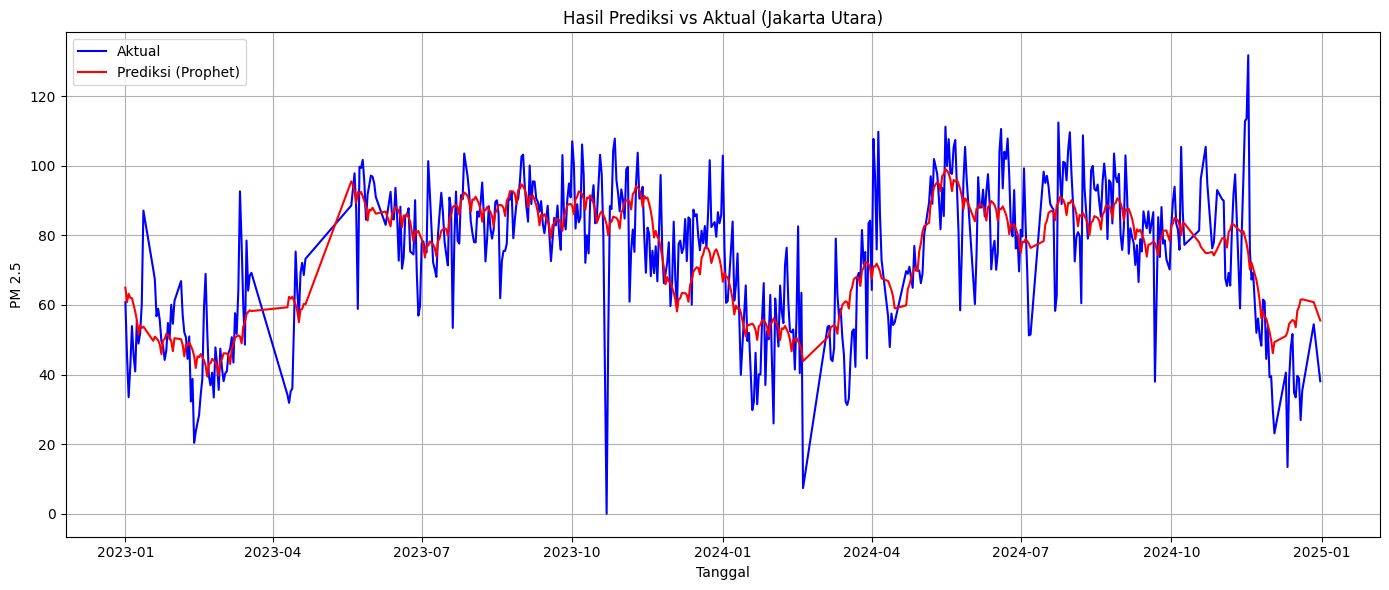

(<prophet.forecaster.Prophet at 0x7d1d70928b00>,
             ds      trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
 0   2023-01-01  72.153482   47.077425   81.123260    72.153482    72.153482   
 1   2023-01-02  72.165262   43.460557   77.102174    72.165262    72.165262   
 2   2023-01-03  72.177043   45.215839   79.085500    72.177043    72.177043   
 3   2023-01-04  72.188823   45.522628   79.836011    72.188823    72.188823   
 4   2023-01-05  72.200604   45.706621   79.966370    72.200604    72.200604   
 ..         ...        ...         ...         ...          ...          ...   
 613 2025-01-26  59.186706   18.390617   52.683096    59.134690    59.248234   
 614 2025-01-27  59.108306   17.304030   51.076220    59.053137    59.172417   
 615 2025-01-28  59.029907   20.101045   54.616110    58.971082    59.098241   
 616 2025-01-29  58.951508   19.077768   54.019804    58.889159    59.025097   
 617 2025-01-30  58.873108   21.553421   55.701331    58.804580    58.9

In [ ]:
# Train Data

run_prophet_pipeline(df_utara, region_name="Jakarta Utara")

#### Model Prophet Jakarta Selatan

08:47:40 - cmdstanpy - INFO - Chain [1] start processing


08:47:40 - cmdstanpy - INFO - Chain [1] done processing



📍 Wilayah: Jakarta Selatan
✅ MAE  : 10.8120
✅ MSE  : 223.8618
✅ RMSE : 14.9620
✅ R²   : 0.3131


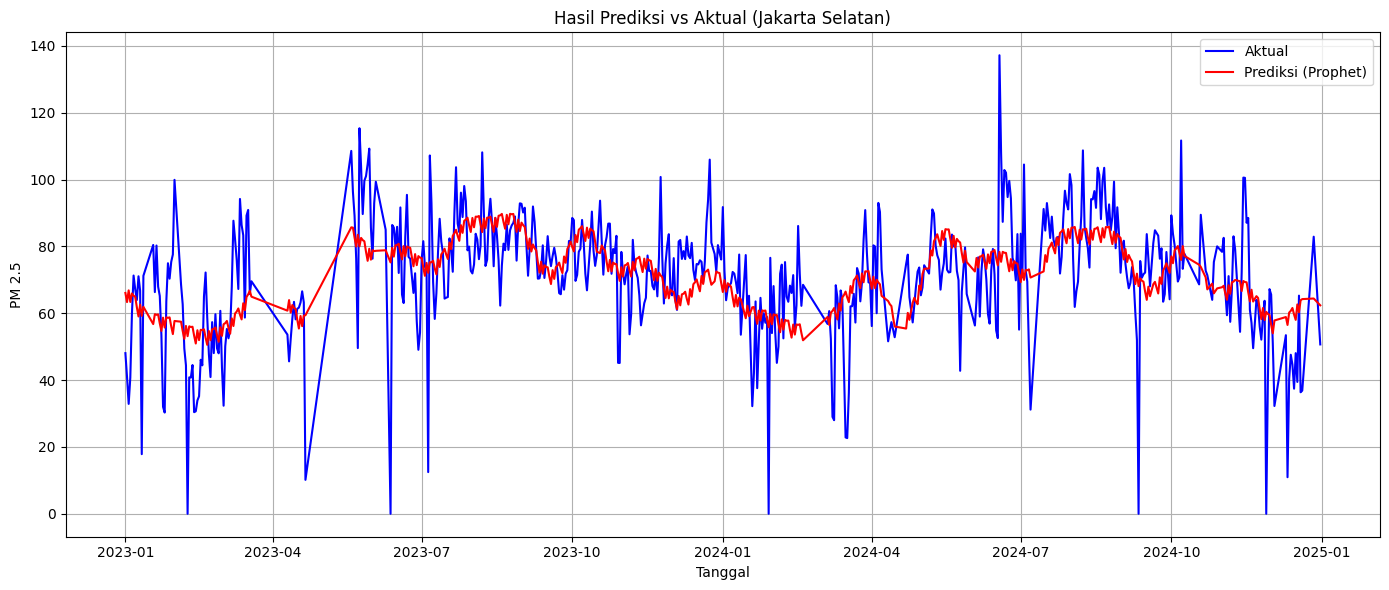

(<prophet.forecaster.Prophet at 0x7d1d70a9ac30>,
             ds      trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
 0   2023-01-01  70.621904   48.194912   85.551520    70.621904    70.621904   
 1   2023-01-02  70.629163   44.570700   83.068401    70.629163    70.629163   
 2   2023-01-03  70.636422   47.231560   86.318992    70.636422    70.636422   
 3   2023-01-04  70.643680   43.446770   80.462431    70.643680    70.643680   
 4   2023-01-05  70.650939   44.722038   85.692633    70.650939    70.650939   
 ..         ...        ...         ...         ...          ...          ...   
 613 2025-01-26  63.998208   31.026795   69.798364    63.976197    64.022808   
 614 2025-01-27  63.970596   27.579598   65.974210    63.946101    63.996534   
 615 2025-01-28  63.942985   32.690940   70.376838    63.917463    63.970431   
 616 2025-01-29  63.915374   28.125566   66.992362    63.888000    63.944868   
 617 2025-01-30  63.887763   33.136432   72.143210    63.857072    63.9

In [83]:
# Train Data

run_prophet_pipeline(df_selatan, region_name="Jakarta Selatan")

#### Model Prophet Jakarta Pusat

08:47:42 - cmdstanpy - INFO - Chain [1] start processing
08:47:42 - cmdstanpy - INFO - Chain [1] done processing



📍 Wilayah: Jakarta Pusat
✅ MAE  : 11.3330
✅ MSE  : 220.5400
✅ RMSE : 14.8506
✅ R²   : 0.5690


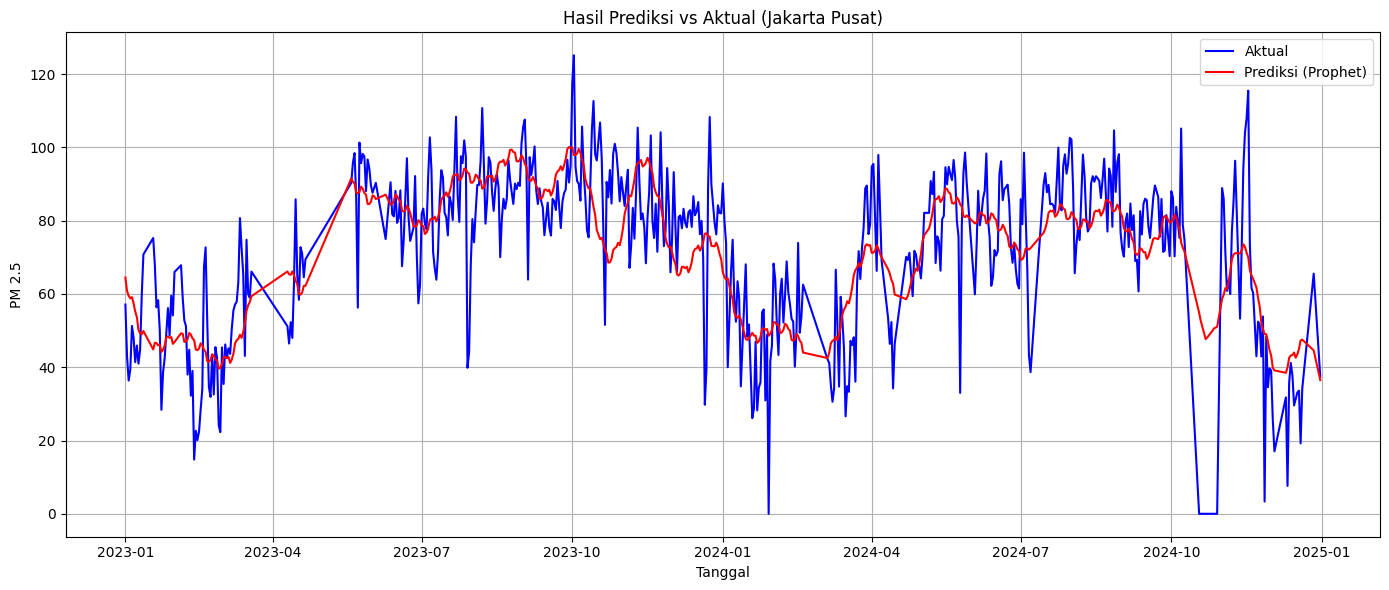

(<prophet.forecaster.Prophet at 0x7d1d70626210>,
             ds      trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
 0   2023-01-01  73.430152   46.317326   84.803644    73.430152    73.430152   
 1   2023-01-02  73.439648   41.784752   78.435164    73.439648    73.439648   
 2   2023-01-03  73.449144   39.904588   77.966925    73.449144    73.449144   
 3   2023-01-04  73.458640   38.103918   76.769985    73.458640    73.458640   
 4   2023-01-05  73.468137   41.863175   77.996211    73.468137    73.468137   
 ..         ...        ...         ...         ...          ...          ...   
 613 2025-01-26  43.465274   -0.753482   35.463111    43.366150    43.541845   
 614 2025-01-27  43.345214   -3.142531   33.095376    43.240671    43.428891   
 615 2025-01-28  43.225153   -3.140992   34.214558    43.115032    43.312981   
 616 2025-01-29  43.105092   -3.714069   35.225348    42.987439    43.197364   
 617 2025-01-30  42.985031   -0.877709   37.694716    42.861798    43.0

In [84]:
# Train Data

run_prophet_pipeline(df_pusat, region_name="Jakarta Pusat")

#### Model Prophet Jakarta Barat

08:47:44 - cmdstanpy - INFO - Chain [1] start processing
08:47:45 - cmdstanpy - INFO - Chain [1] done processing



📍 Wilayah: Jakarta Barat
✅ MAE  : 12.2619
✅ MSE  : 276.2791
✅ RMSE : 16.6216
✅ R²   : 0.8308


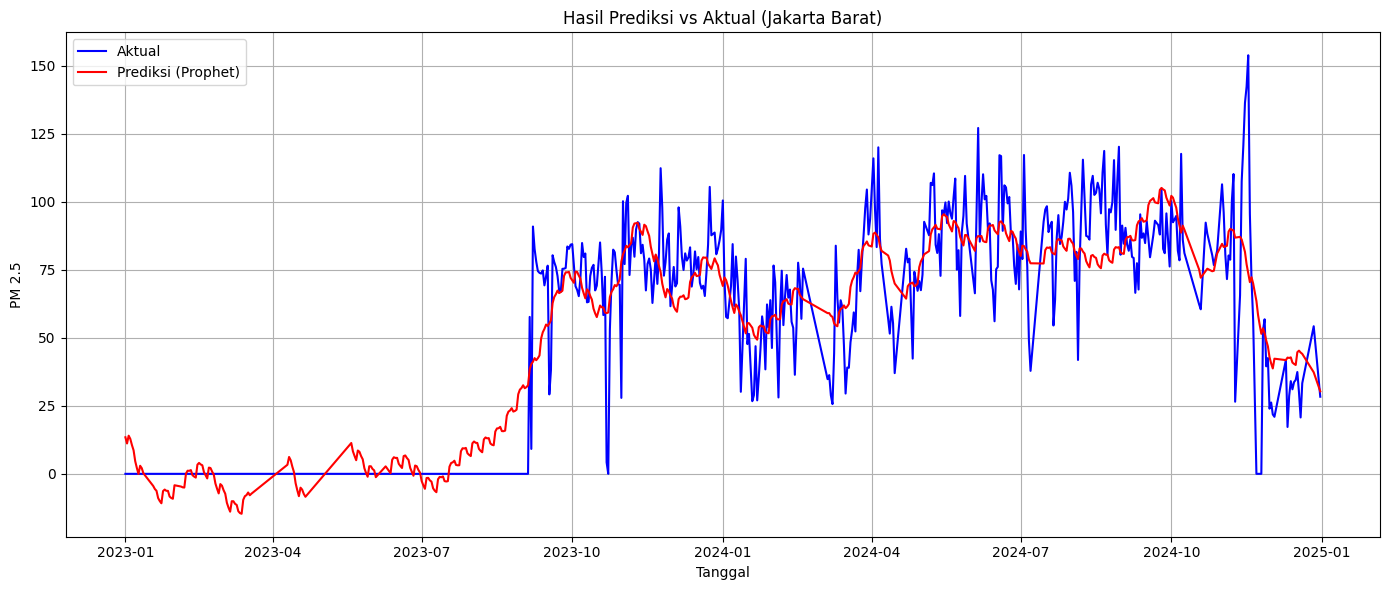

(<prophet.forecaster.Prophet at 0x7d1d65e166c0>,
             ds     trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
 0   2023-01-01  5.180189   -7.567072   34.948560     5.180189     5.180189   
 1   2023-01-02  5.250817   -9.652591   31.836654     5.250817     5.250817   
 2   2023-01-03  5.321446   -8.546185   34.710176     5.321446     5.321446   
 3   2023-01-04  5.392074   -9.241262   35.023720     5.392074     5.392074   
 4   2023-01-05  5.462703  -10.246476   32.146010     5.462703     5.462703   
 ..         ...       ...         ...         ...          ...          ...   
 613 2025-01-26  4.106426  -33.451439    7.737248     3.415365     4.777754   
 614 2025-01-27  3.591083  -34.828354    7.878699     2.854260     4.309749   
 615 2025-01-28  3.075740  -30.483415   12.456224     2.331966     3.851657   
 616 2025-01-29  2.560397  -30.490204   11.598473     1.759565     3.406323   
 617 2025-01-30  2.045054  -31.369626   10.849457     1.182506     2.935107   
 
 

In [85]:
# Train Data

run_prophet_pipeline(df_barat, region_name="Jakarta Barat")

#### Model Prophet Jakarta Timur

08:47:50 - cmdstanpy - INFO - Chain [1] start processing
08:47:50 - cmdstanpy - INFO - Chain [1] done processing



📍 Wilayah: Jakarta Timur
✅ MAE  : 14.1211
✅ MSE  : 403.1580
✅ RMSE : 20.0788
✅ R²   : 0.5791


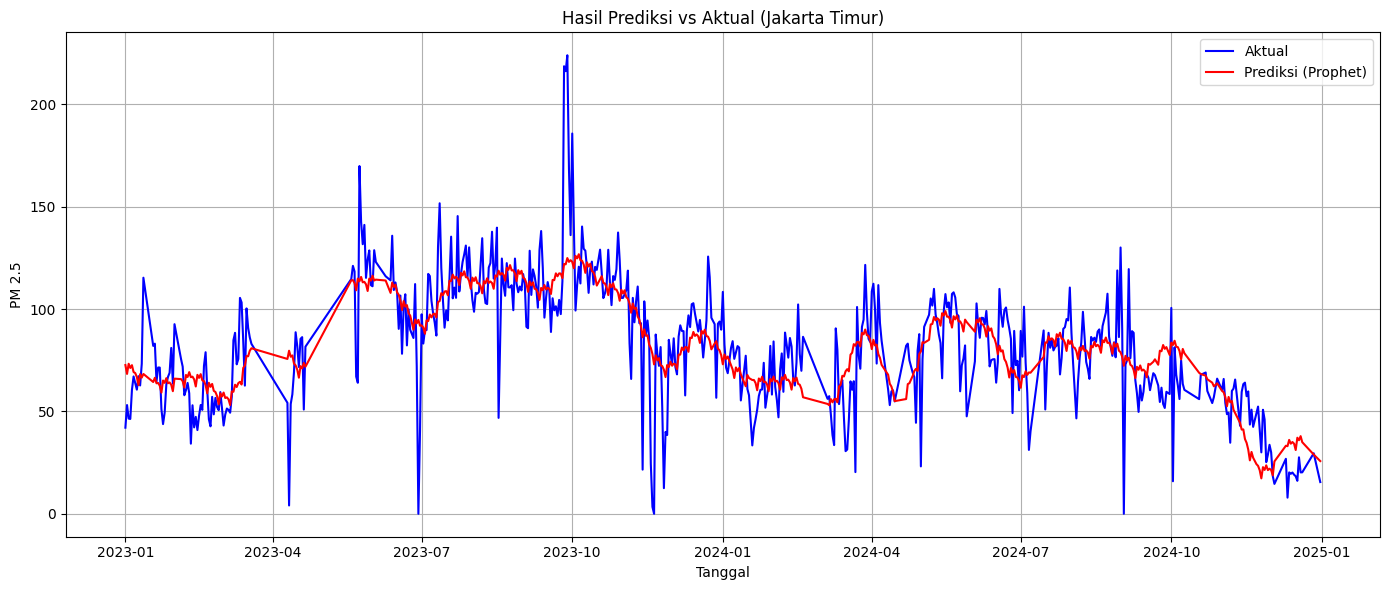

(<prophet.forecaster.Prophet at 0x7d1d7068d040>,
             ds      trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
 0   2023-01-01  89.895811   47.792251   98.902858    89.895811    89.895811   
 1   2023-01-02  89.919714   42.226155   94.360218    89.919714    89.919714   
 2   2023-01-03  89.943617   45.820319   99.618084    89.943617    89.943617   
 3   2023-01-04  89.967521   44.017843   96.282236    89.967521    89.967521   
 4   2023-01-05  89.991424   46.212681   97.184342    89.991424    89.991424   
 ..         ...        ...         ...         ...          ...          ...   
 613 2025-01-26  35.918868  -16.027648   32.412144    35.802989    36.034152   
 614 2025-01-27  35.763936  -20.216976   31.369942    35.639794    35.889679   
 615 2025-01-28  35.609005  -16.414849   35.262409    35.471773    35.741557   
 616 2025-01-29  35.454073  -16.008639   33.412935    35.306044    35.594398   
 617 2025-01-30  35.299141  -12.744204   36.736286    35.140950    35.4

In [86]:
# Train Data

run_prophet_pipeline(df_timur, region_name="Jakarta Timur")